# Import library dan gathering data

In [ ]:
import pandas as pd
import pandas as pd

# Baca dataset menggunakan pandas
data = pd.read_csv('https://docs.google.com/spreadsheets/d/1HckTu-lY4uRwTxVIpT2l3mxW-QDsic2PzZVZTJfVY50/export?format=csv&gid=2103122221')

In [ ]:
data.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,TIMELINESS,Timeliness,DECIMALS,Decimals
0,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,NRGC,Energy consumption,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
1,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,NRGC,Energy consumption,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
2,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,NRGC,Energy consumption,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
3,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,NRGC,Energy consumption,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
4,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,NRGC,Energy consumption,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two


Pada dataset ini kami menggunakan beberapa variabel yaitu GHG emission yang menggambarkan data total emisi gas rumah kaca, Real GDP per capita yang menggambarkan pertumbuhan ekonomi, Sektor-sektor Energy consumption, dan Renewable Energy Supply dari TOP 4 negara dengan industri terbesar di dunia (China, Amerika Serikat, Jepang, dan Jerman) dan juga Indonesia untuk perbandingan pendekatan dan insight yang diperoleh lebih bermanfaat. Rentang waktu dari tahun 1995 hingga tahun 2020 diambil karena beberapa alasan yaitu, data dari rentang waktu yang panjang yaitu 25 tahun memberikan cukup informasi untuk menganalisis tren jangka panjang terkait konteks sustainability. Dengan menggunakan data dari periode ini, kita dapat melihat bagaimana pertumbuhan ekonomi, energi terbarukan, dan beberapa sektor konsumsi energi tersebut berpengaruh terhadap emisi gas rumah kaca pada negara negara yang bisa dibilang maju dalam aspek industri. Apakah negara tersebut sudah efisien dalam penggunaan energi dan penanggulangan gas emisi rumah kacanya? seberapa efisien kah Indonesia dalam penggunaan energi dan penanggulangan gas emisi rumah kacanya? Startegi atau kebijakan apa yang bisa diadopsi di Indonesia untuk menjadi lebih baik kedepannya.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 1300 non-null   object 
 1   STRUCTURE_ID              1300 non-null   object 
 2   STRUCTURE_NAME            1300 non-null   object 
 3   ACTION                    1300 non-null   object 
 4   REF_AREA                  1300 non-null   object 
 5   Reference area            1300 non-null   object 
 6   FREQ                      1300 non-null   object 
 7   Frequency of observation  1300 non-null   object 
 8   MEASURE                   1300 non-null   object 
 9   Measure                   1300 non-null   object 
 10  UNIT_MEASURE              1300 non-null   object 
 11  Unit of measure           1300 non-null   object 
 12  ACTIVITY                  1300 non-null   object 
 13  Economic activity         1300 non-null   object 
 14  TIME_PER

In [ ]:
# ganti nama kolom
data_renamed = data.rename(columns={
    'REF_AREA': 'Country_Region',
    'MEASURE': 'Measure_Code',
    'Measure': 'Measure_Description',
    'FREQ': 'Observation_Frequency',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Values',
    'UNIT': 'Unit_of_Measurement',
    'STRUCTURE': 'Data_Type',
    'TIMELINESS': 'Timeliness_Description',
    'DECIMALS': 'Number_of_Decimals'
})

In [ ]:
selected_columns = data_renamed[['Country_Region', 'Year', 'Values', 'Measure_Description', 'Economic activity']]
selected_columns.head()

,Country_Region,Year,Values,Measure_Description,Economic activity
0,CHN,2020,4.09,Energy consumption,Services
1,CHN,2012,3.72,Energy consumption,Services
2,CHN,2013,3.82,Energy consumption,Services
3,CHN,2014,3.76,Energy consumption,Services
4,CHN,2015,3.94,Energy consumption,Services


In [ ]:
# Melakukan pivot
df_pivot = selected_columns.pivot_table(index=['Country_Region', 'Year'],
                           columns=['Measure_Description', 'Economic activity'],
                           values='Values')

# Mengatur nama kolom
df_pivot.columns.name = None  # Menghapus nama kolom yang dihasilkan oleh pivot_table
df_pivot.reset_index(inplace=True)  # Mengubah index menjadi kolom biasa

df_pivot

Measure_Description Country_Region  Year                Energy consumption  \
Economic activity                        Agriculture, forestry and fishing   
0                              CHN  1995                              4.34   
1                              CHN  1996                              2.91   
2                              CHN  1997                              4.55   
3                              CHN  1998                              4.84   
4                              CHN  1999                              5.25   
..                             ...   ...                               ...   
125                            USA  2016                              1.34   
126                            USA  2017                              1.37   
127                            USA  2018                              1.33   
128                            USA  2019                              1.36   
129                            USA  2020                              1.39   

Measure_Description                                                 \
Economic activity   Industry (except construction)  Other Services   
0                                            42.06  45.17     2.97   
1                                            40.90  44.60     4.10   
2                                            39.32  46.16     3.60   
3                                            41.44  43.94     3.70   
4                                            38.23  45.23     4.28   
..                                             ...    ...      ...   
125                                          17.58  26.44    13.80   
126                                          17.21  26.80    13.66   
127                                          17.31  27.73    13.69   
128                                          17.00  27.69    13.74   
129                                          18.26  28.81    13.86   

Measure_Description                            Production-based GHG emissions  \
Economic activity   Transportation and storage         Total - all activities   
0                                         5.47                       2093.080   
1                                         7.49                       2188.595   
2                                         6.36                       2168.325   
3                                         6.07                       2198.835   
4                                         7.01                       2162.975   
..                                         ...                            ...   
125                                      40.84                       2987.885   
126                                      40.96                       2972.920   
127                                      39.94                       3047.405   
128                                      40.21                       2958.100   
129                                      37.68                       2684.885   

Measure_Description    Real GDP per capita Renewable energy supply  
Economic activity   Total - all activities  Total - all activities  
0                                  2475.91            1.112275e+08  
1                                  2699.09            1.110900e+08  
2                                  2925.76            1.117376e+08  
3                                  3132.45            1.112354e+08  
4                                  3349.35            1.108111e+08  
..                                     ...                     ...  
125                               57658.67            7.641168e+07  
126                               58703.15            7.959972e+07  
127                               60127.22            8.455222e+07  
128                               61330.65            8.579483e+07  
129                               59397.55            8.449632e+07  

[130 rows x 10 columns]

#**Assignment Chapter 2 : Data Preprocessing**

#C.1 Data Preparation

## 1.Mencari missing values dan mengatasi masalah secara missing values

In [ ]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   (Country_Region, )                                        130 non-null    object 
 1   (Year, )                                                  130 non-null    int64  
 2   (Energy consumption, Agriculture, forestry and fishing)   130 non-null    float64
 3   (Energy consumption, Industry (except construction))      130 non-null    float64
 4   (Energy consumption, Other)                               130 non-null    float64
 5   (Energy consumption, Services)                            130 non-null    float64
 6   (Energy consumption, Transportation and storage)          130 non-null    float64
 7   (Production-based GHG emissions, Total - all activities)  130 non-null    float64
 8   (Real GDP per capita

Interpretasi: Dengan syntax 'data.info( )' dapat dilihat hasil outputnya menampilkan 'Dtype' atau tipe data dan 'Non-Null Count' atau jumlah data yang tidak kosong (Null). Ditampilkan bahwa nilai Non-Null pada setiap variabel adalah 130 sama seperti jumlah pada 'RangeIndex' sehingga tidak ada missing values pada dataset. Hal ini menunjukkan bahwa data yang tersedia lengkap dan konsisten sehingga memungkinkan untuk dilakukan analisis secara mendalam tanpa perlu menangani kekurangan data.

## 2.Mencari duplicate value dan menyelesaikan masalah duplicate value

In [ ]:
# Mencari baris yang duplikat
duplicates = df_pivot[df_pivot.duplicated()]

# Menampilkan duplikat
print(duplicates)

Empty DataFrame
Columns: [(Country_Region, ), (Year, ), (Energy consumption, Agriculture, forestry and fishing), (Energy consumption, Industry (except construction)), (Energy consumption, Other), (Energy consumption, Services), (Energy consumption, Transportation and storage), (Production-based GHG emissions, Total - all activities), (Real GDP per capita, Total - all activities), (Renewable energy supply, Total - all activities)]
Index: []


Interpretasi: Berdasarkan hasil yang telah diperoleh adalah tidak terdapat duplicate value. Ini berarti setiap entri dalam dataset adalah unik, sehingga tidak ada baris yang sama yang harus dihapus atau ditangani lebih lanjut.

## 3.Memeriksa outlier dan menangani outlier

In [ ]:
import numpy as np

#menghitung banyaknya outlier tiap feature

def count_outliers_using_IQR(df_pivot, column_name):
    # df_pivot[column_name] untuk memilih spesific coloumn
    Q1 = np.percentile(df_pivot[column_name], 25, interpolation='midpoint')
    Q3 = np.percentile(df_pivot[column_name], 75, interpolation='midpoint')

    IQR = Q3 - Q1

    upper = df_pivot[column_name] >= (Q3 + 1.5 * IQR)
    lower = df_pivot[column_name] <= (Q1 - 1.5 * IQR)

    print(column_name, " : ", len(np.where(upper)[0]) + len(np.where(lower)[0]))

# panggil the function dengan DataFrame dan nama column
for column in df_pivot.select_dtypes(include=['float64']).columns: # khusus untuk column numerik
    count_outliers_using_IQR(df_pivot, column)

('Energy consumption', 'Agriculture, forestry and fishing')  :  4
('Energy consumption', 'Industry (except construction)')  :  0
('Energy consumption', 'Other')  :  0
('Energy consumption', 'Services')  :  0
('Energy consumption', 'Transportation and storage')  :  1
('Production-based GHG emissions', 'Total - all activities')  :  0
('Real GDP per capita', 'Total - all activities')  :  0
('Renewable energy supply', 'Total - all activities')  :  1


<ipython-input-11-b4e1f64672f1>:19: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  count_outliers_using_IQR(df_pivot, column)


Interpretasi: Berdasarkan hasil perhitungan dengan IQR dapat dilihat ternyata terdapat 3 variabel yaitu 'Energy consumption sektor Agriculture, forestry and fishing', 'Energy consumption sektor Transportation and storage', dan 'Renewable energy supply' yang terdapat outlier didalamnya sehingga perlu diatasi terlebih dahulu.

REMOVE OUTLIER

In [ ]:
#Fungsi untuk menghitung THE MASK yang menandai variabel mana yang berada di luar batas (outlier)

def calc_elements_upper_and_lower_than_IQR(df_pivot, column_name):
    Q1 = np.percentile(df_pivot[column_name], 25, interpolation = 'midpoint')
    Q3 = np.percentile(df_pivot[column_name], 75, interpolation = 'midpoint')

    IQR = Q3 - Q1

    # Dibatas batas atas
    upper_element_mask = df_pivot[column_name] >= (Q3 + 1.5 * IQR)
    # Dibawah batas bawah
    lower_element_mask = df_pivot[column_name] <= (Q1 - 1.5 * IQR)

    return upper_element_mask, lower_element_mask

In [ ]:
#Membuat A MASK - menandai variabel mana yang berada di luar batas (outlier)

#List variabel yang sesuai
list_of_masks_for_outlier_removal = []

for column in df_pivot.select_dtypes(include=['float64']).columns:
    x, y = calc_elements_upper_and_lower_than_IQR(df_pivot, column)
    list_of_masks_for_outlier_removal.append(x)
    list_of_masks_for_outlier_removal.append(y)

mask_for_outlier_removal_iqr = np.any(list_of_masks_for_outlier_removal, axis = 0)

<ipython-input-13-d6d7707ba135>:7: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  x, y = calc_elements_upper_and_lower_than_IQR(df_pivot, column)


In [ ]:
#Posisi Outlier

list_of_records_with_outliers_iqr = np.where(mask_for_outlier_removal_iqr)

In [ ]:
#Jumlah Total Outlier

len(list_of_records_with_outliers_iqr[0])

5

In [ ]:
#Membuat dataset baru yang telah ditangani outliernya dengan IQR

dataset_IQR = df_pivot.drop(list_of_records_with_outliers_iqr[0])

In [ ]:
dataset_IQR.shape

(125, 10)

Interpretasi: Setelah dibersihkan dari outlier dataset baru berubah menjadi 'dataset_IQR' yang memiliki 125 baris dan 10 kolom baru.

##4.Memeriksa imbalance data

In [ ]:
print(dataset_IQR.dtypes)

Measure_Description             Economic activity                
Country_Region                                                        object
Year                                                                   int64
Energy consumption              Agriculture, forestry and fishing    float64
                                Industry (except construction)       float64
                                Other                                float64
                                Services                             float64
                                Transportation and storage           float64
Production-based GHG emissions  Total - all activities               float64
Real GDP per capita             Total - all activities               float64
Renewable energy supply         Total - all activities               float64
dtype: object


Interpretasi: Imbalance data adalah kondisi dimana distribusi kelas atau label dalam dataset tidak seimbang. Jika distribusi jumlah kelas sangat berbeda, maka data tersebut dikatakan imbalance. Untuk mengecek imbalance data, biasanya digunakan untuk dataset klasifikasi yang memiliki label kategori. Dalam dataset kelompok kami, semua data nya bertipe numerikal tanpa label sehingga konsep imbalance tidak berlaku secara langsung.

##5.Melakukan Feature Encoding

In [ ]:
print(dataset_IQR.dtypes)

Measure_Description             Economic activity                
Country_Region                                                        object
Year                                                                   int64
Energy consumption              Agriculture, forestry and fishing    float64
                                Industry (except construction)       float64
                                Other                                float64
                                Services                             float64
                                Transportation and storage           float64
Production-based GHG emissions  Total - all activities               float64
Real GDP per capita             Total - all activities               float64
Renewable energy supply         Total - all activities               float64
dtype: object


In [ ]:
dataset_IQR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 1 to 129
Data columns (total 10 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   (Country_Region, )                                        125 non-null    object 
 1   (Year, )                                                  125 non-null    int64  
 2   (Energy consumption, Agriculture, forestry and fishing)   125 non-null    float64
 3   (Energy consumption, Industry (except construction))      125 non-null    float64
 4   (Energy consumption, Other)                               125 non-null    float64
 5   (Energy consumption, Services)                            125 non-null    float64
 6   (Energy consumption, Transportation and storage)          125 non-null    float64
 7   (Production-based GHG emissions, Total - all activities)  125 non-null    float64
 8   (Real GDP per capita, Tot

In [ ]:
# import the label encoder library

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
dataset_clean = dataset_IQR.copy()
dataset_clean['Country_Region'] = encoder.fit_transform(dataset_IQR['Country_Region'])

dataset_clean.head(55)

Measure_Description Country_Region  Year                Energy consumption  \
Economic activity                        Agriculture, forestry and fishing   
1                                0  1996                              2.91   
5                                0  2000                              2.39   
6                                0  2001                              2.51   
7                                0  2002                              2.59   
8                                0  2003                              2.69   
9                                0  2004                              2.63   
10                               0  2005                              2.56   
11                               0  2006                              2.51   
12                               0  2007                              2.33   
13                               0  2008                              2.19   
14                               0  2009                              2.17   
15                               0  2010                              2.10   
16                               0  2011                              2.07   
17                               0  2012                              2.05   
18                               0  2013                              2.10   
19                               0  2014                              2.05   
20                               0  2015                              2.09   
21                               0  2016                              2.15   
22                               0  2017                              2.22   
23                               0  2018                              2.07   
24                               0  2019                              2.05   
26                               1  1995                              0.85   
27                               1  1996                              0.84   
28                               1  1997                              0.85   
29                               1  1998                              0.86   
30                               1  1999                              0.12   
31                               1  2000                              0.13   
32                               1  2001                              0.12   
33                               1  2002                              0.11   
34                               1  2003                              0.08   
35                               1  2004                              0.09   
36                               1  2005                              0.09   
37                               1  2006                              0.10   
38                               1  2007                              0.16   
39                               1  2008                              0.15   
40                               1  2009                              0.19   
41                               1  2010                              0.56   
42                               1  2011                              0.60   
43                               1  2012                              0.59   
44                               1  2013                              0.55   
45                               1  2014                              0.70   
46                               1  2015                              0.66   
47                               1  2016                              0.67   
48                               1  2017                              0.62   
49                               1  2018                              1.61   
50                               1  2019                              1.62   
51                               1  2020                              1.68   
52                               2  1995                              2.11   
53                               2  1996                              2.10   
54                    

Interpretasi: Feature encoding dilakukan untuk mengubah data kualitatif menjadi kuantitaitf. Disini kami menggunakan label encoding yaitu mengganti data kategorikal menjadi data numerik sesuai urutan abjad.
Bisa dilihat untuk Country_Region yang menggunakan 0 untuk China, 1 untuk Germany, 2 untuk Indonesia, dan begitu seterusnya.

#C.2 Statistics for Data Science & EDA

##1.Mengelaborasi Features dan Tipe Data

In [ ]:
# Daftar setiap fitur dan klasifikasinya
# Daftar setiap fitur dan klasifikasinya
fitur = {
    'Country_Region': 'Object',
    'Year_': 'Nominal', # Dapat dianggap nominal, meskipun merepresentasikan tahun
    'Production-based GHG emissions': 'Numerik',
    'Energy consumption (Agriculture, forestry and fishing)': 'Numerik',
    'Energy consumption (Industry(except construction))': 'Numerik',
    'Energy consumption (Services)': 'Numerik',
    'Energy consumption (Transportation and storage)': 'Numerik',
    'Energy consumption (Other)': 'Numerik',
    'Production-based GHG emissions_Total - all activities': 'Numerik',
    'Real GDP per capita_Total - all activities': 'Numerik',
    'Renewable energy supply_Total - all activities': 'Numerik'

}

# Tampilkan tipe fitur
for fitur, tipe in fitur.items():
    print(f"Fitur: {fitur}, Tipe: {tipe}")
for kolom in df_pivot.columns:
    if df_pivot[kolom].dtype == 'object':
        print(f'{kolom}: Nominal')
    elif df_pivot[kolom].dtype in ['int64', 'float64']:
        print(f'{kolom}: Numerik')


Fitur: Country_Region, Tipe: Object
Fitur: Year_, Tipe: Nominal
Fitur: Production-based GHG emissions, Tipe: Numerik
Fitur: Energy consumption (Agriculture, forestry and fishing), Tipe: Numerik
Fitur: Energy consumption (Industry(except construction)), Tipe: Numerik
Fitur: Energy consumption (Services), Tipe: Numerik
Fitur: Energy consumption (Transportation and storage), Tipe: Numerik
Fitur: Energy consumption (Other), Tipe: Numerik
Fitur: Production-based GHG emissions_Total - all activities, Tipe: Numerik
Fitur: Real GDP per capita_Total - all activities, Tipe: Numerik
Fitur: Renewable energy supply_Total - all activities, Tipe: Numerik
('Country_Region', ''): Nominal
('Year', ''): Numerik
('Energy consumption', 'Agriculture, forestry and fishing'): Numerik
('Energy consumption', 'Industry (except construction)'): Numerik
('Energy consumption', 'Other'): Numerik
('Energy consumption', 'Services'): Numerik
('Energy consumption', 'Transportation and storage'): Numerik
('Production-bas

Interpretasi:

1. **Country_Region:** Nominal, data ini digunakan sebagai label untuk mengelompokkan data berdasarkan wilayah, tanpa memiliki makna kuantitatif atau matematis.

2. **Year_:** Nominal, meskipun mewakili tahun, data ini berfungsi sebagai label waktu tanpa makna numerik yang dihitung, menjadikannya variabel kategorikal.

3. **Production-based GHG emissions:** Numerik, menunjukkan total emisi gas rumah kaca yang dihasilkan dari kegiatan produksi, dinyatakan dalam nilai kuantitatif yang dapat dianalisis.

4. **Energy consumption (Agriculture, forestry and fishing):** Numerik, mengukur konsumsi energi dalam sektor pertanian, kehutanan, dan perikanan yang bisa dianalisis secara kuantitatif.

5. **Energy consumption (Industry (except construction)):** Numerik, menggambarkan total energi yang dikonsumsi dalam sektor industri (kecuali konstruksi), yang dinyatakan dalam angka.

6. **Energy consumption (Services):** Numerik, menunjukkan konsumsi energi dalam sektor layanan, yang dapat diukur dan dianalisis kuantitatif.

7. **Energy consumption (Transportation and storage):** Numerik, mencakup total energi yang digunakan dalam transportasi dan penyimpanan, yang dinyatakan dalam satuan yang dapat dihitung.

8. **Energy consumption (Other):** Numerik, mewakili konsumsi energi dari aktivitas yang tidak termasuk dalam kategori utama lainnya, dan diukur dalam satuan yang sama.

9. **Production-based GHG emissions_Total - all activities:** Numerik, nilai ini mengukur emisi gas rumah kaca secara keseluruhan dari semua aktivitas produksi, yang dapat dianalisis secara kuantitatif.

10. **Real GDP per capita_Total - all activities:** Numerik, menunjukkan nilai PDB per kapita secara keseluruhan untuk semua aktivitas, yang dinyatakan dalam nilai ekonomi per individu dan dapat dianalisis.

11. **Renewable energy supply_Total - all activities:** Numerik, menunjukkan suplai energi terbarukan dari seluruh aktivitas, dinyatakan dalam satuan energi yang dapat dihitung.

Dengan demikian, fitur-fitur berlabel **Nominal** berfungsi sebagai kategori atau label tanpa nilai numerik, sementara fitur **Numerik** digunakan untuk data yang memiliki nilai kuantitatif, memungkinkan dianalisis secara matematis.

##2.Menjelaskan kondisi dan perbedaan penggunaan mean, median, dan modus

In [ ]:
# Menghitung Mean setiap variabel
mean_ghg = dataset_clean['Production-based GHG emissions', 'Total - all activities'].mean()
mean_gdp = dataset_clean['Real GDP per capita', 'Total - all activities'].mean()
mean_res = dataset_clean['Renewable energy supply', 'Total - all activities'].mean()
mean_energy1 = dataset_clean['Energy consumption', 'Agriculture, forestry and fishing'].mean()
mean_energy2 = dataset_clean['Energy consumption', 'Industry (except construction)'].mean()
mean_energy3 = dataset_clean['Energy consumption', 'Other'].mean()
mean_energy4 = dataset_clean['Energy consumption', 'Services'].mean()
mean_energy5 = dataset_clean['Energy consumption', 'Transportation and storage'].mean()

# Menampilkan hasil perhitungan
print(f"Mean dari 'Production-based GHG emissions_Total - all activities': {mean_ghg}")
print(f"Mean dari 'Real GDP per capita_Total - all activities': {mean_gdp}")
print(f"Mean dari 'Renewable energy supply_Total - all activities': {mean_res}")
print(f"Mean dari 'Energy consumption_Agriculture, forestry and fishing': {mean_energy1}")
print(f"Mean dari 'Energy consumption_Industry (except construction)': {mean_energy2}")
print(f"Mean dari 'Energy consumption_Other': {mean_energy3}")
print(f"Mean dari 'Energy consumption_Services': {mean_energy4}")
print(f"Mean dari 'Energy consumption_Transportation and storage': {mean_energy5}")

Mean dari 'Production-based GHG emissions_Total - all activities': 1748.1788800000004
Mean dari 'Real GDP per capita_Total - all activities': 31100.52944
Mean dari 'Renewable energy supply_Total - all activities': 40434761.388639994
Mean dari 'Energy consumption_Agriculture, forestry and fishing': 1.6000800000000004
Mean dari 'Energy consumption_Industry (except construction)': 30.717119999999998
Mean dari 'Energy consumption_Other': 30.814160000000005
Mean dari 'Energy consumption_Services': 10.310399999999998
Mean dari 'Energy consumption_Transportation and storage': 26.558720000000005


Interpretasi:
Mean (rata-rata) adalah jumlah total nilai dalam data dibagi dengan jumlah data itu sendiri. Mean cocok digunakan ketika kita ingin melihat gambaran keseluruhan atau "rata-rata" yang melibatkan seluruh data, asalkan data tersebut tidak memiliki outlier signifikan atau distribusi data cukup simetris. Kondisi dan perbedaan penggunaan mean pada setiap variabel sebagai berikut:
1. Penggunaaan mean untuk **Production-based GHG emissions** memberikan gambaran tentang rata-rata emisi gas rumah kaca berbasis produksi untuk semua kegiatan ekonomi di Indonesia. Meskipun ini memberikan pandangan umum tentang seberapa besar emisi yang dihasilkan oleh aktivitas ekonomi secara keseluruhan, nilai mean ini bisa dipengaruhi oleh sektor-sektor tertentu yang memiliki emisi sangat tinggi atau rendah. Misalnya, sektor-sektor yang sangat intensif karbon seperti industri dan transportasi dapat memberikan pengaruh yang besar terhadap hasil rata-rata ini.
2. Penggunaan mean untuk **Real GDP per capita** memberikan gambaran umum mengenai tingkat kemakmuran ekonomi per kapita. Namun, rata-rata ini sering kali tidak mencerminkan kondisi ekonomi mayoritas penduduk, terutama jika ada kelompok kecil orang dengan pendapatan yang sangat tinggi (outlier) yang dapat meningkatkan nilai mean secara signifikan. Dalam hal ini, meskipun rata-rata GDP per kapita terlihat tinggi, banyak masyarakat mungkin tidak merasakan peningkatan ekonomi yang sama.
3. Penggunaan mean untuk **Renewable energy supply** menggambarkan rata-rata pasokan energi terbarukan yang tersedia secara keseluruhan. Meskipun ini memberikan gambaran tentang seberapa banyak energi terbarukan yang tersedia, nilai rata-rata ini dapat terdistorsi oleh distribusi energi yang tidak merata. Misalnya, wilayah-wilayah besar dengan pasokan energi terbarukan yang lebih banyak bisa mempengaruhi nilai rata-rata, sementara wilayah kecil dengan pasokan energi terbatas mungkin tidak tercermin dalam angka rata-rata ini.
4. Penggunaan mean untuk **sektor-sektor konsumsi energi** memberikan gambaran umum tentang rata-rata konsumsi energi di sektor pertanian, industri, jasa, transportasi, dan sektor lainnya. Rata-rata ini membantu kita memahami konsumsi energi di setiap sektor, tetapi, seperti pada variabel lainnya, mean ini dapat dipengaruhi oleh distribusi energi yang tidak merata.

In [ ]:
# Menghitung Median setiap variabel
median_ghg = dataset_clean['Production-based GHG emissions', 'Total - all activities'].median()
median_gdp = dataset_clean['Real GDP per capita', 'Total - all activities'].median()
median_res = dataset_clean['Renewable energy supply', 'Total - all activities'].median()
median_energy1 = dataset_clean['Energy consumption', 'Agriculture, forestry and fishing'].median()
median_energy2 = dataset_clean['Energy consumption', 'Industry (except construction)'].median()
median_energy3 = dataset_clean['Energy consumption', 'Other'].median()
median_energy4 = dataset_clean['Energy consumption', 'Services'].median()
median_energy5 = dataset_clean['Energy consumption', 'Transportation and storage'].median()

# Menampilkan hasil perhitungan
print(f"Median dari 'Production-based GHG emissions_Total - all activities': {median_ghg}")
print(f"Median dari 'Real GDP per capita_Total - all activities': {median_gdp}")
print(f"Median dari 'Renewable energy supply_Total - all activities': {median_res}")
print(f"Median dari 'Energy consumption_Agriculture, forestry and fishing': {median_energy1}")
print(f"Median dari 'Energy consumption_Industry (except construction)': {median_energy2}")
print(f"Median dari 'Energy consumption_Other': {median_energy3}")
print(f"Median dari 'Energy consumption_Services': {median_energy4}")
print(f"Median dari 'Energy consumption_Transportation and storage': {median_energy5}")

Median dari 'Production-based GHG emissions_Total - all activities': 675.5400000000001
Median dari 'Real GDP per capita_Total - all activities': 38541.34
Median dari 'Renewable energy supply_Total - all activities': 17892698.334999997
Median dari 'Energy consumption_Agriculture, forestry and fishing': 1.66
Median dari 'Energy consumption_Industry (except construction)': 29.51
Median dari 'Energy consumption_Other': 28.23
Median dari 'Energy consumption_Services': 12.67
Median dari 'Energy consumption_Transportation and storage': 25.04


Interpretasi:
Median adalah nilai tengah yang membagi dataset menjadi dua bagian yang sama besar, dimana setengah data berada di bawah median, dan setengahnya lagi di atas. Median dapat digunakan ketika ada outlier atau distribusi tidak normal karena lebih kuat terhadap pengaruh nilai ekstrem. Cocok untuk data yang memiliki distribusi miring. Kondisi dan perbedaan penggunaan median pada setiap variabel sebagai berikut:
1. Median pada **Production-based GHG emissions** memberikan gambaran yang lebih realistis tentang rata-rata emisi gas rumah kaca berbasis produksi. Median ini tidak terpengaruh oleh sektor-sektor yang mungkin sangat efisien atau tidak efisien dalam menghasilkan emisi. Jika ada sektor yang menghasilkan emisi yang sangat tinggi atau rendah, median akan memberikan nilai yang lebih representatif mengenai distribusi emisi pada umumnya.
2. Median pada **Real GDP per capita** lebih mewakili kondisi ekonomi mayoritas masyarakat daripada mean, karena median tidak terdistorsi oleh pendapatan yang sangat tinggi yang dimiliki oleh sebagian kecil orang. Ini penting dalam konteks ketidakmerataan pendapatan, dimana beberapa individu dengan pendapatan sangat tinggi dapat meningkatkan nilai rata-rata (mean), sementara median akan menunjukkan angka yang lebih menggambarkan keadaan ekonomi kebanyakan penduduk.
3. Median pada **Renewable energy supply** menggambarkan pasokan energi terbarukan dengan cara yang lebih seimbang. Mengingat bahwa distribusi energi terbarukan mungkin tidak merata di seluruh wilayah atau sektor, penggunaan median memberikan gambaran yang lebih realistis tentang pasokan energi terbarukan yang tersedia bagi mayoritas sektor, terlepas dari daerah atau sektor dengan pasokan energi yang sangat tinggi.
4. Median pada **sektor-sektor konsumsi energi** membantu mengurangi pengaruh dari nilai ekstrem, seperti konsumsi energi yang sangat tinggi pada sektor industri. Sebagai contoh, sektor industri besar mungkin mengonsumsi energi jauh lebih banyak daripada sektor lainnya, dan dengan menggunakan median, kita mendapatkan gambaran yang lebih representatif tentang penggunaan energi di sektor-sektor lain yang lebih kecil atau tidak terlalu padat energi.


In [ ]:
# Menghitung Modus setiap variabel
mode_ghg = dataset_clean['Production-based GHG emissions', 'Total - all activities'].mode() [0]
mode_gdp = dataset_clean['Real GDP per capita', 'Total - all activities'].mode() [0]
mode_res = dataset_clean['Renewable energy supply', 'Total - all activities'].mode() [0]
mode_energy1 = dataset_clean['Energy consumption', 'Agriculture, forestry and fishing'].mode() [0]
mode_energy2 = dataset_clean['Energy consumption', 'Industry (except construction)'].mode() [0]
mode_energy3 = dataset_clean['Energy consumption', 'Other'].mode() [0]
mode_energy4 = dataset_clean['Energy consumption', 'Services'].mode() [0]
mode_energy5 = dataset_clean['Energy consumption', 'Transportation and storage'].mode() [0]

# Menampilkan hasil perhitungan
print(f"Modus dari 'Production-based GHG emissions_Total - all activities': {mode_ghg}")
print(f"Modus dari 'Real GDP per capita_Total - all activities': {mode_gdp}")
print(f"Modus dari 'Renewable energy supply_Total - all activities': {mode_res}")
print(f"Modus dari 'Energy consumption_Agriculture, forestry and fishing': {mode_energy1}")
print(f"Modus dari 'Energy consumption_Industry (except construction)': {mode_energy2}")
print(f"Modus dari 'Energy consumption_Other': {mode_energy3}")
print(f"Modus dari 'Energy consumption_Services': {mode_energy4}")
print(f"Modus dari 'Energy consumption_Transportation and storage': {mode_energy5}")

Modus dari 'Production-based GHG emissions_Total - all activities': 253.8
Modus dari 'Real GDP per capita_Total - all activities': 2699.09
Modus dari 'Renewable energy supply_Total - all activities': 2988421.64
Modus dari 'Energy consumption_Agriculture, forestry and fishing': 1.44
Modus dari 'Energy consumption_Industry (except construction)': 21.85
Modus dari 'Energy consumption_Other': 25.43
Modus dari 'Energy consumption_Services': 3.17
Modus dari 'Energy consumption_Transportation and storage': 24.52


Interpretasi: Modus adalah nilai yang paling sering muncul dalam kumpulan data. Dalam beberapa kasus, dataset bisa memiliki lebih dari satu modus (bimodal atau multimodal). Modus lebih baik digunakan untuk data kategorikal atau data yang sering mengulang nilai yang sama, terutama ketika kita tertarik pada nilai yang paling sering muncul dalam distribusi. Kondisi dan perbedaan penggunaan modus pada setiap variabel sebagai berikut:
1. Modus pada **Production-based GHG emissions** menunjukkan tingkat emisi yang paling sering muncul di seluruh aktivitas. Ini mungkin kurang informatif jika emisi sangat bervariasi antar sektor atau daerah. Namun, modus tetap berguna untuk mengenali tren emisi yang paling umum, terutama jika ada pola tertentu di sektor-sektor dengan tingkat emisi serupa.

2. Modus pada **Real GDP per capita** memberikan gambaran tentang tingkat pendapatan yang paling umum di dalam populasi. Ini bisa mengindikasikan kelompok pendapatan terbesar, misalnya jika sebagian besar masyarakat berada dalam kelompok pendapatan menengah ke bawah. Namun, dalam distribusi pendapatan yang sangat tidak merata, modus mungkin tidak memberikan gambaran lengkap tentang distribusi pendapatan secara keseluruhan.

3. Modus pada **Renewable energy supply** menunjukkan tingkat pasokan energi yang paling sering muncul. Ini dapat membantu mengenali pola umum atau kapasitas pasokan yang dominan. Namun, jika variasi dalam data sangat besar, nilai modus mungkin kurang representatif dalam menggambarkan keseluruhan distribusi pasokan energi terbarukan.

4. Modus pada **sektor-sektor konsumsi energi** menunjukkan tingkat konsumsi energi yang paling umum dalam aktivitas tersebut. Misalnya, jika sektor "other" merupakan pengguna energi terbesar, modus dapat memberikan gambaran tentang tingkat konsumsi energi yang paling sering terjadi di sektor tersebut. Namun, seperti variabel lainnya, modus konsumsi energi di berbagai sektor bisa kurang informatif jika distribusi nilai dalam setiap sektor sangat beragam, terutama bila tidak ada nilai yang sering terulang.

##3.Menemukan dan mendeskripsikan statistical five summaries

In [ ]:
#Melihat nilai statistical five summaries
summary = dataset_clean.describe()
print(summary)

Measure_Description Country_Region         Year  \
Economic activity                                 
count                   125.000000   125.000000   
mean                      2.080000  2007.728000   
std                       1.388896     7.362039   
min                       0.000000  1995.000000   
25%                       1.000000  2002.000000   
50%                       2.000000  2008.000000   
75%                       3.000000  2014.000000   
max                       4.000000  2020.000000   

Measure_Description                Energy consumption  \
Economic activity   Agriculture, forestry and fishing   
count                                      125.000000   
mean                                         1.600080   
std                                          0.775778   
min                                          0.080000   
25%                                          1.100000   
50%                                          1.660000   
75%                              

Interpretasi: Statistical five summaries terdiri dari nilai Min, Q1, Q2(median), Q3, dan Max. Dapat diperoleh nilai statistical five summaries setiap variabel adalah sebagai berikut:
1. Pada variabel **Production-based GHG emissions** didapatkan nilai minimum 253.8, nilai Q1 531.345, nilai Q2 (median) 675.54, nilai Q3 3132.97, dan nilai maksimum 6227.57.
2. Pada variabel **Real GDP per capita** didapatkan nilai minimum 2699.09, nilai Q1 9811.31, nilai Q2 (median) 38541.34, nilai Q3 46302.16, dan nilai maksimum 61330.65.
3. Pada variabel **Energy consumption (Agriculture, forestry and fishing)** didapatkan nilai minimum 0.08, nilai Q1 1.10, nilai Q2 (median) 1.66, nilai Q3 2.10, dan nilai maksimum 3.24.
4. Pada variabel **Energy consumption (Industry (except construction))** didapatkan nilai minimum 17, nilai Q1 22.03, nilai Q2 (median) 29.51, nilai Q3 35.59, dan nilai maksimum 55.75.
5. Pada variabel **Energy consumption (Services)** didapatkan nilai minimum 2.32, nilai Q1 3.87, nilai Q2 (median) 12.67, nilai Q3 14.53, dan nilai maksimum 18.22.
6. Pada variabel **Energy consumption (Transportation and storage)** didapatkan nilai minimum 7.49, nilai Q1 23.62, nilai Q2 (median) 25.04, nilai Q3 35.94, dan nilai maksimum 40.96.
7. Pada variabel **Energy consumption (Other)** didapatkan nilai minimum 20.30, nilai Q1 26.81, nilai Q2 (median) 28.23, nilai Q3 35.96 dan nilai maksimum 45.91.
8. Pada variabel **Renewable Energy Supply** didapatkan nilai minimum 2.98, nilai Q1 1.07, nilai Q2 (median) 1.78, nilai Q3 6.29 dan nilai maksimum 1.61.

##4.Mendeskripsikan distribusi data

In [ ]:
# Mengimpor library yang diperlukan
import seaborn as sns
import matplotlib.pyplot as plt

* GHG Emission

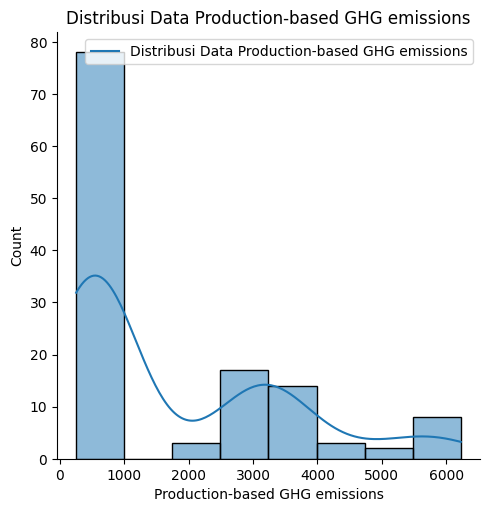

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Production-based GHG emissions', 'Total - all activities'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Production-based GHG emissions')
plt.xlabel("Production-based GHG emissions")

# Menambahkan legenda
plt.legend(['Distribusi Data Production-based GHG emissions'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi:
Berdasarkan grafik distribusi *Production-based GHG emissions* metode yang digunakan dalam analisis ini adalah plot distribusi dengan *Kernel Density Estimate (KDE)*, yang membantu memvisualisasikan sebaran data secara lebih halus. Pada grafik ini, tampak bahwa data emisi memiliki distribusi yang asimetris, yang menunjukkan adanya *skewness*. Mayoritas data berkumpul pada rentang emisi yang lebih rendah, sekitar di bawah 1000, yang menyebabkan adanya satu puncak utama yang tinggi di awal rentang tersebut. Hal ini menunjukkan bahwa sebagian besar aktivitas menghasilkan emisi yang relatif rendah. Selain itu, terlihat ada beberapa puncak kecil pada rentang yang lebih tinggi (sekitar 3000–4000), tetapi tidak sebanyak puncak awal, menunjukkan distribusi yang menurun seiring meningkatnya nilai emisi. Ini mungkin menunjukkan beberapa aktivitas dengan emisi yang lebih tinggi, tetapi jumlahnya jauh lebih sedikit. Distribusi ini secara keseluruhan tampak *right-skewed* atau miring ke kanan karena terdapat lebih banyak data pada nilai emisi yang rendah dibandingkan yang tinggi, dengan penurunan yang lambat di sisi kanan.

*   Real GDP per capita


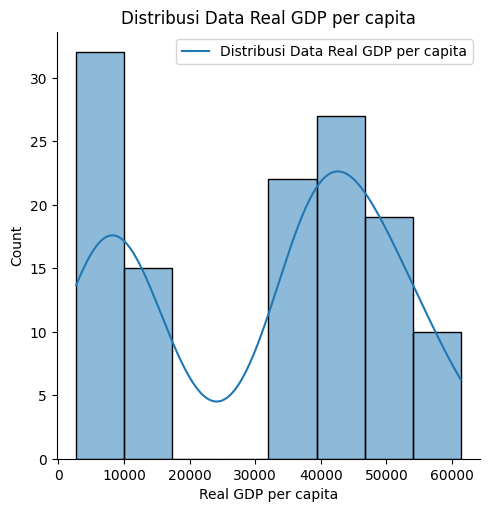

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Real GDP per capita', 'Total - all activities'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Real GDP per capita')
plt.xlabel("Real GDP per capita")

# Menambahkan legenda
plt.legend(['Distribusi Data Real GDP per capita'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi:

Berdasarkan grafik di atas, distribusi **Real GDP per capita** dari beberapa negara menunjukkan bahwa mayoritas data berkumpul di sisi kiri grafik, yang mengindikasikan bahwa distribusinya cenderung right-skewed (condong ke kanan). Hal ini menandakan bahwa meskipun ada beberapa negara yang memiliki GDP per kapita yang tinggi, mayoritas negara dalam dataset ini masih berada pada level ekonomi menengah hingga rendah.

Distribusi ini mengungkapkan bahwa sebagian besar negara dalam sampel memiliki GDP per kapita di rentang yang lebih rendah, sedangkan hanya sedikit negara yang mencapai GDP per kapita yang sangat tinggi. Hal ini bisa jadi mencerminkan ketimpangan dalam distribusi kekayaan atau kapasitas ekonomi antar negara di dunia. Metode yang digunakan dalam analisis ini adalah plot distribusi dengan *Kernel Density Estimate (KDE)*, yang membantu memvisualisasikan sebaran data secara lebih halus.

* Renewable Energy Supply

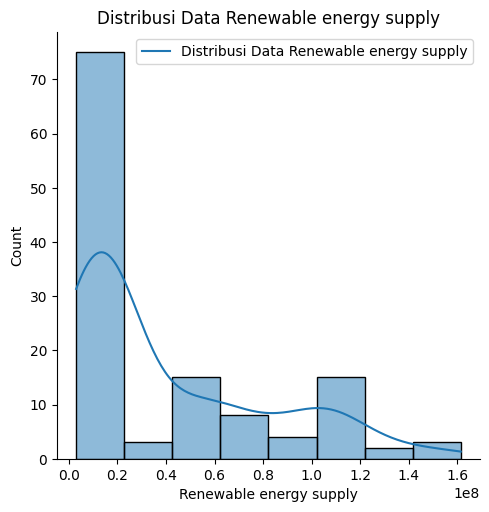

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Renewable energy supply', 'Total - all activities'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Renewable energy supply')
plt.xlabel("Renewable energy supply")

# Menambahkan legenda
plt.legend(['Distribusi Data Renewable energy supply'], loc='best')

# Menampilkan plot
plt.show()

*Interpretasi*:

Distribusi Renewable Energy Supply dari beberapa negara menunjukkan bahwa mayoritas data berkumpul di sisi kiri grafik, yang mengindikasikan bahwa distribusinya cenderung right-skewed (condong ke kanan). Hal ini mengindikasikan bahwa meskipun ada beberapa negara yang memiliki pasokan energi terbarukan yang tinggi, mayoritas negara dalam dataset ini masih memiliki pasokan energi terbarukan yang relatif rendah.

Distribusi ini mencerminkan bahwa sebagian besar negara menggunakan sumber energi terbarukan dalam jumlah yang lebih rendah, sementara hanya sedikit negara yang memiliki pasokan energi terbarukan yang sangat tinggi. Hal ini dapat menggambarkan perbedaan dalam kapasitas atau komitmen penggunaan energi terbarukan di antara negara-negara. Metode yang digunakan dalam analisis ini adalah plot distribusi dengan *Kernel Density Estimate (KDE)*, yang membantu memvisualisasikan sebaran data secara lebih halus.

*   Energy consumption (Agriculture, forestry, and fishing)


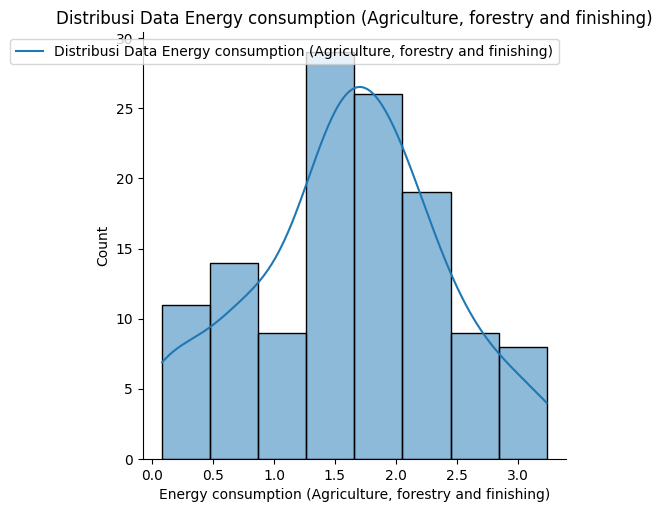

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Energy consumption', 'Agriculture, forestry and fishing'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Energy consumption (Agriculture, forestry and finishing)')
plt.xlabel("Energy consumption (Agriculture, forestry and finishing)")

# Menambahkan legenda
plt.legend(['Distribusi Data Energy consumption (Agriculture, forestry and finishing)'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi:

Distribusi Energy Consumption pada sektor Agriculture, Forestry, and Fishing menunjukkan bahwa mayoritas data terpusat di tengah grafik, membentuk distribusi yang cenderung normal atau simetris. Artinya, sebagian besar negara memiliki konsumsi energi di sektor ini dalam kisaran menengah, dengan sedikit negara yang memiliki konsumsi energi yang sangat rendah atau sangat tinggi.

Distribusi ini menunjukkan bahwa penggunaan energi pada sektor Agriculture, Forestry, and Fishing cukup merata di berbagai negara, dengan jumlah negara yang hampir seimbang di kedua sisi rata-rata konsumsi energi. Hal ini mungkin mengindikasikan bahwa sektor ini memiliki kebutuhan energi yang serupa di berbagai negara, atau bahwa faktor-faktor yang mempengaruhi konsumsi energi di sektor ini bersifat konsisten di antara negara-negara. Metode yang digunakan dalam analisis ini adalah plot distribusi dengan *Kernel Density Estimate (KDE)*, yang membantu memvisualisasikan sebaran data secara lebih halus.

*   Energy consumption (Industry (except construction))


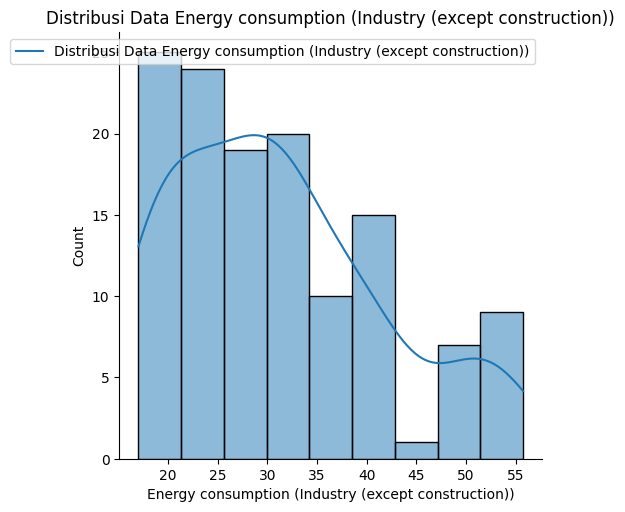

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(df_pivot['Energy consumption', 'Industry (except construction)'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Energy consumption (Industry (except construction))')
plt.xlabel("Energy consumption (Industry (except construction))")

# Menambahkan legenda
plt.legend(['Distribusi Data Energy consumption (Industry (except construction))'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi:

distribusi Energy Consumption pada sektor Industry (except construction) menunjukkan bahwa mayoritas data berada di sisi kiri grafik, membentuk distribusi yang left-skewed (condong ke kiri). Ini menunjukkan bahwa sebagian besar negara memiliki konsumsi energi di sektor industri dalam kisaran yang lebih rendah hingga sedang, sementara hanya sedikit negara yang memiliki konsumsi energi yang sangat tinggi di sektor ini.

Distribusi ini dapat mengindikasikan bahwa kebutuhan energi di sektor industri (selain konstruksi) cenderung lebih rendah pada sebagian besar negara, dengan beberapa negara yang mengonsumsi energi lebih tinggi mungkin disebabkan oleh ukuran industri atau intensitas penggunaan energi yang lebih besar di sektor ini. Metode yang digunakan dalam analisis ini adalah plot distribusi dengan *Kernel Density Estimate (KDE)*, yang membantu memvisualisasikan sebaran data secara lebih halus.

*   Energy consumption (Services)


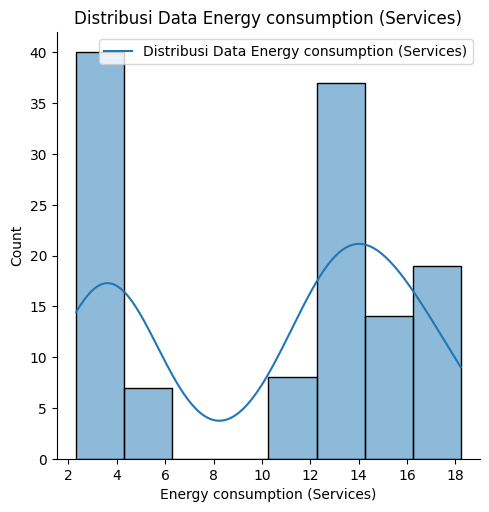

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Energy consumption', 'Services'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Energy consumption (Services)')
plt.xlabel("Energy consumption (Services)")

# Menambahkan legenda
plt.legend(['Distribusi Data Energy consumption (Services)'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi: Pada grafik distribusi *konsumsi energi untuk sektor Service* ini, terlihat bahwa data memiliki pola yang cukup simetris namun kemungkinan memiliki *skewness* atau kemencengan. Distribusi ini tampak memiliki dua puncak utama, satu di sekitar nilai 4 dan satu lagi di sekitar nilai 14, yang menunjukkan bahwa konsumsi energi di sektor ini tidak terpusat pada satu titik, melainkan tersebar pada dua nilai berbeda (disebut distribusi bimodal). Namun, secara keseluruhan, tidak dapat ditentukan dengan jelas kemiringan dari grafik tersebut.



*   Energy consumption (Transportation and storage)




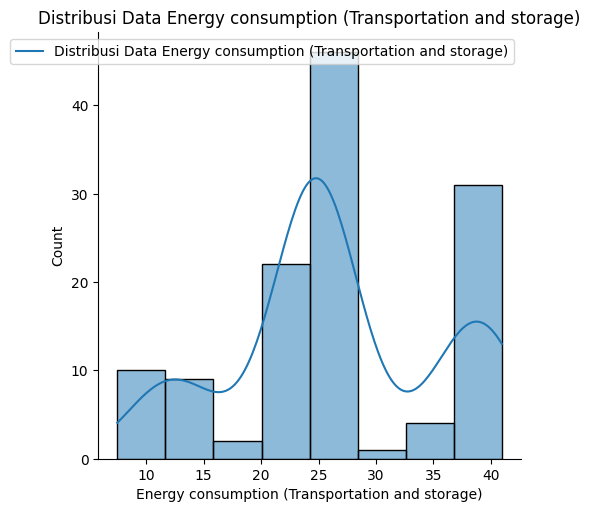

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Energy consumption', 'Transportation and storage'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Energy consumption (Transportation and storage)')
plt.xlabel("Energy consumption (Transportation and storage)")

# Menambahkan legenda
plt.legend(['Distribusi Data Energy consumption (Transportation and storage)'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi: Pada grafik distribusi *konsumsi energi untuk sektor Transportation and storage* ini, terlihat bahwa data memiliki pola yang tidak simetris dan kemungkinan memiliki *skewness* atau kemencengan. Distribusi ini tampak memiliki dua puncak utama, satu di sekitar nilai 25 dan satu lagi di sekitar nilai 40, yang menunjukkan bahwa konsumsi energi di sektor ini tidak terpusat pada satu titik, melainkan tersebar pada dua nilai berbeda (disebut distribusi bimodal). Namun, secara keseluruhan, jika melihat kemiringan di sekitar puncak pertama, distribusi ini tampak sedikit miring (skewed) ke arah kiri karena terdapat lebih banyak data di sisi kanan puncak dibandingkan sisi kirinya.

* Energy consumption (Other)

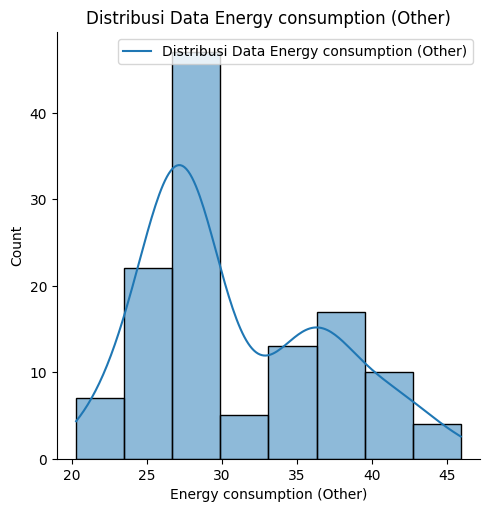

In [ ]:
# Membuat plot distribusi dengan KDE (Kernel Density Estimate)
sns.displot(dataset_clean['Energy consumption', 'Other'], kde=True)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Data Energy consumption (Other)')
plt.xlabel("Energy consumption (Other)")

# Menambahkan legenda
plt.legend(['Distribusi Data Energy consumption (Other)'], loc='best')

# Menampilkan plot
plt.show()

Interpretasi: Berdasarkan grafik di atas, distribusi *Energy consumption (Other)* untuk periode 1995 hingga 2020 menunjukkan bahwa bisa dibilang cukup simetris namun cenderung miring ke kanan (right-skew). Data ini menunjukkan bahwa konsumsi energi pada sektor ini cenderung berpusat di sekitar angka 30, sementara konsumsi yang jauh lebih rendah atau lebih tinggi relatif jarang terjadi. Metode yang digunakan dalam analisis ini adalah plot distribusi dengan *Kernel Density Estimate (KDE)*, yang membantu memvisualisasikan sebaran data secara lebih halus.

## 5.Hitunglah korelasi antar-fitur

Matriks Korelasi untuk 0
Measure_Description                                                             Energy consumption  \
Economic activity                                                Agriculture, forestry and fishing   
Measure_Description            Economic activity                                                     
Energy consumption             Agriculture, forestry and fishing                          1.000000   
                               Industry (except construction)                            -0.736706   
                               Other                                                      0.840829   
                               Services                                                  -0.391097   
                               Transportation and storage                                -0.764591   
Production-based GHG emissions Total - all activities                                    -0.889380   
Real GDP per capita            Total - all activities    

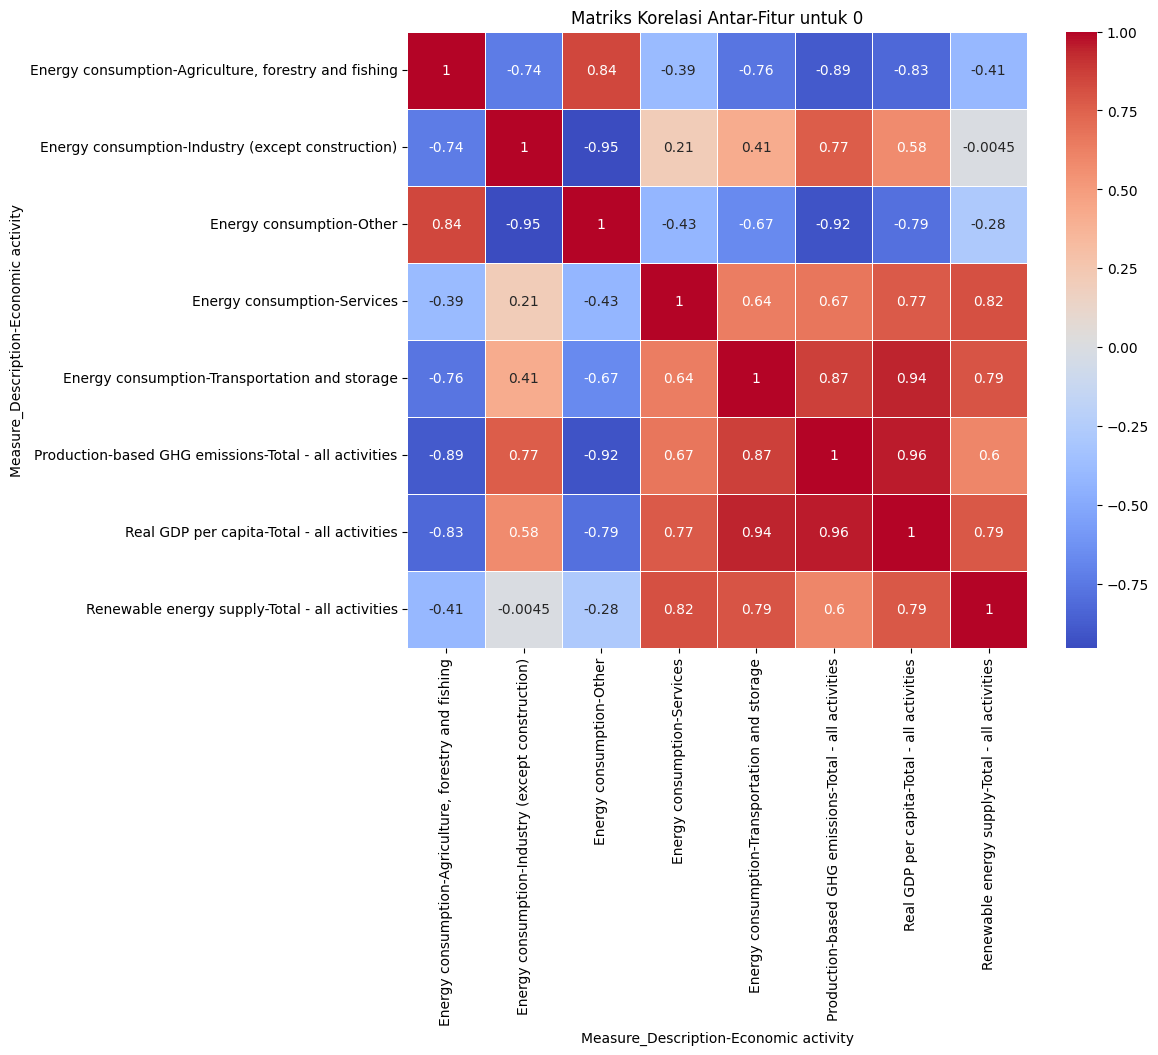

Matriks Korelasi untuk 1
Measure_Description                                                             Energy consumption  \
Economic activity                                                Agriculture, forestry and fishing   
Measure_Description            Economic activity                                                     
Energy consumption             Agriculture, forestry and fishing                          1.000000   
                               Industry (except construction)                             0.404151   
                               Other                                                     -0.290688   
                               Services                                                  -0.295328   
                               Transportation and storage                                 0.177310   
Production-based GHG emissions Total - all activities                                    -0.606106   
Real GDP per capita            Total - all activities    

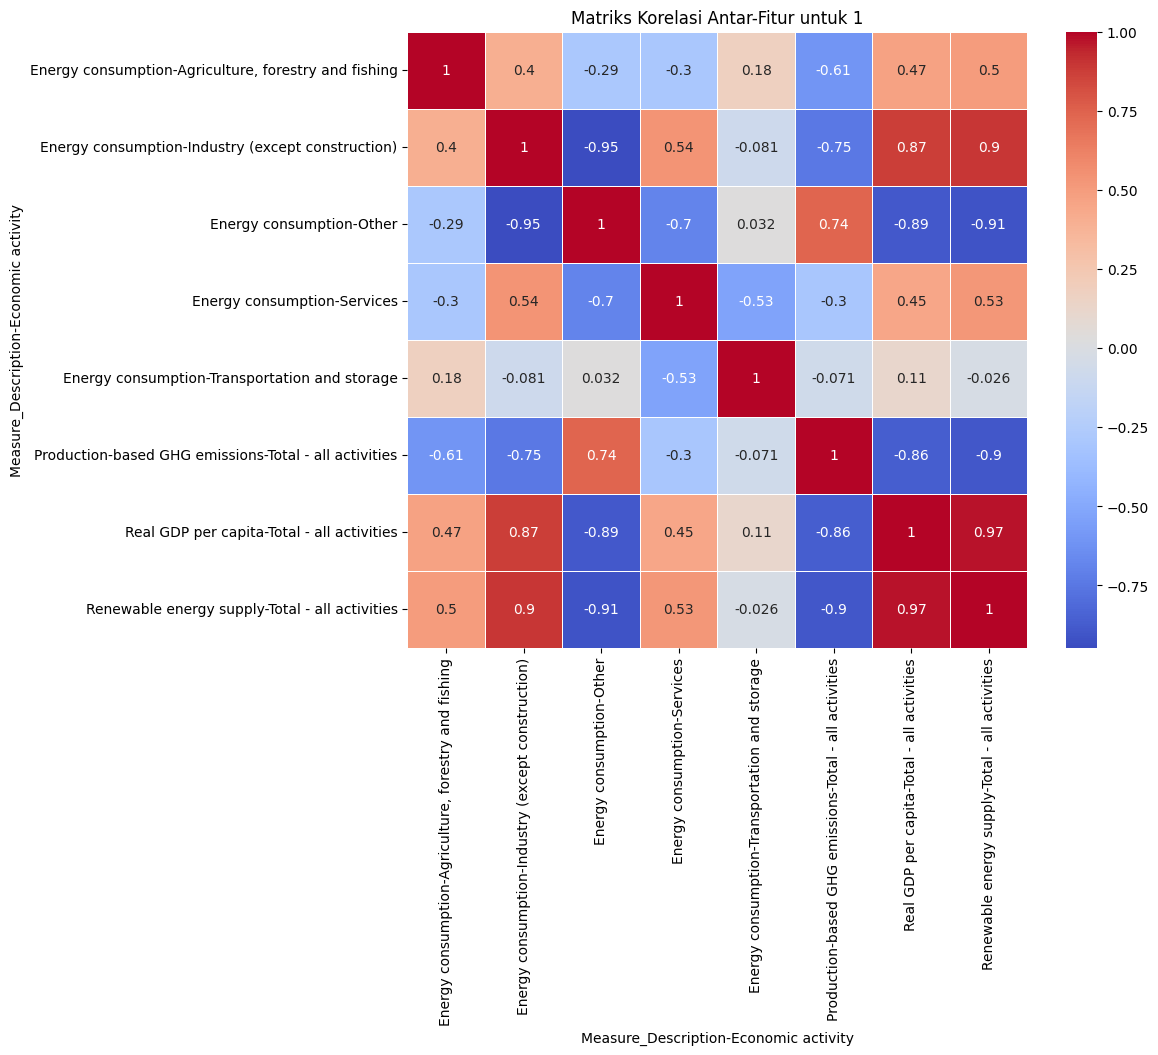

Matriks Korelasi untuk 2
Measure_Description                                                             Energy consumption  \
Economic activity                                                Agriculture, forestry and fishing   
Measure_Description            Economic activity                                                     
Energy consumption             Agriculture, forestry and fishing                          1.000000   
                               Industry (except construction)                            -0.336060   
                               Other                                                      0.623375   
                               Services                                                  -0.449202   
                               Transportation and storage                                -0.565584   
Production-based GHG emissions Total - all activities                                    -0.647352   
Real GDP per capita            Total - all activities    

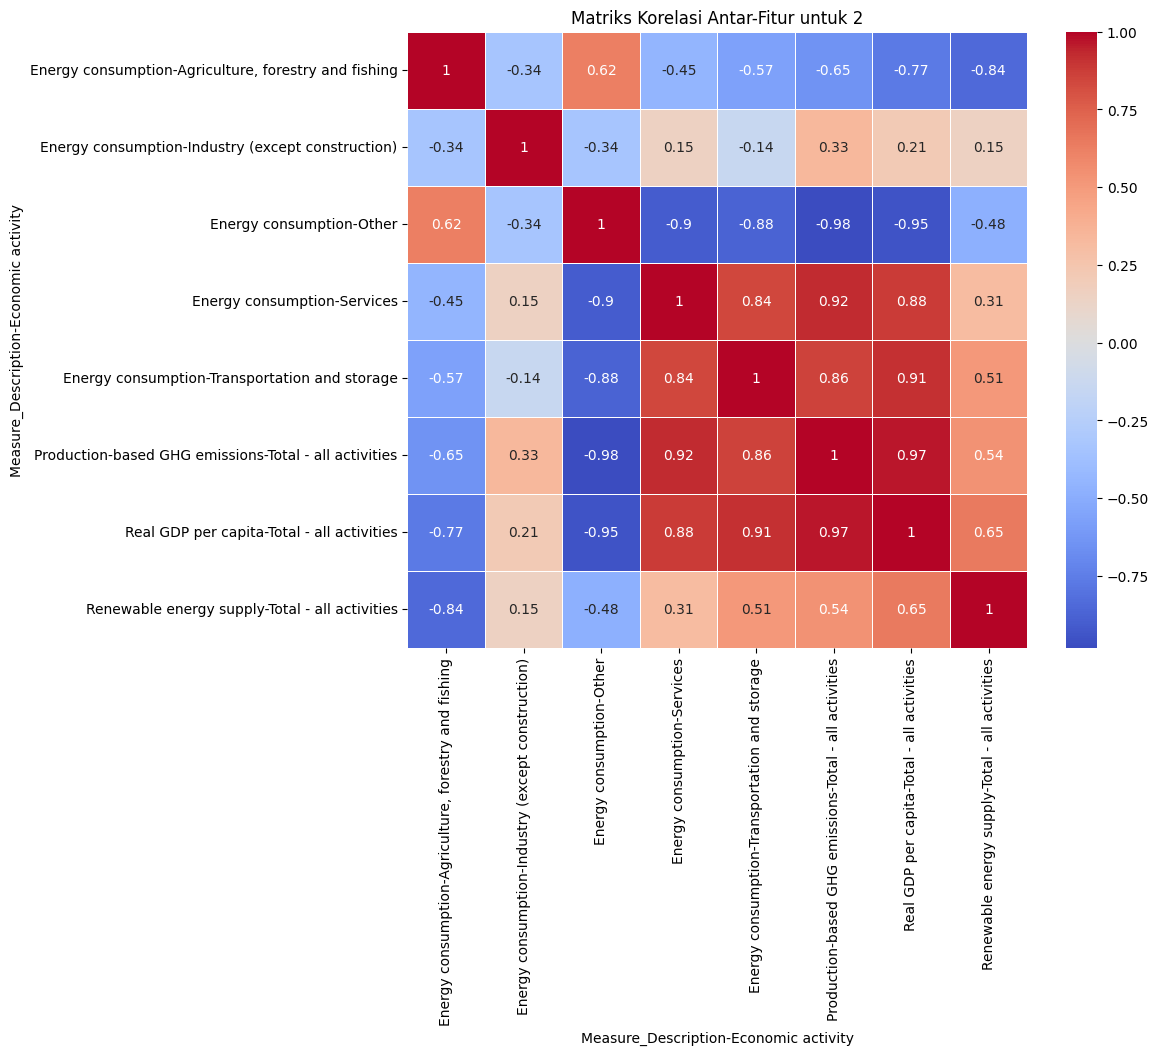

Matriks Korelasi untuk 3
Measure_Description                                                             Energy consumption  \
Economic activity                                                Agriculture, forestry and fishing   
Measure_Description            Economic activity                                                     
Energy consumption             Agriculture, forestry and fishing                          1.000000   
                               Industry (except construction)                             0.218383   
                               Other                                                     -0.181935   
                               Services                                                  -0.512552   
                               Transportation and storage                                 0.474590   
Production-based GHG emissions Total - all activities                                    -0.327637   
Real GDP per capita            Total - all activities    

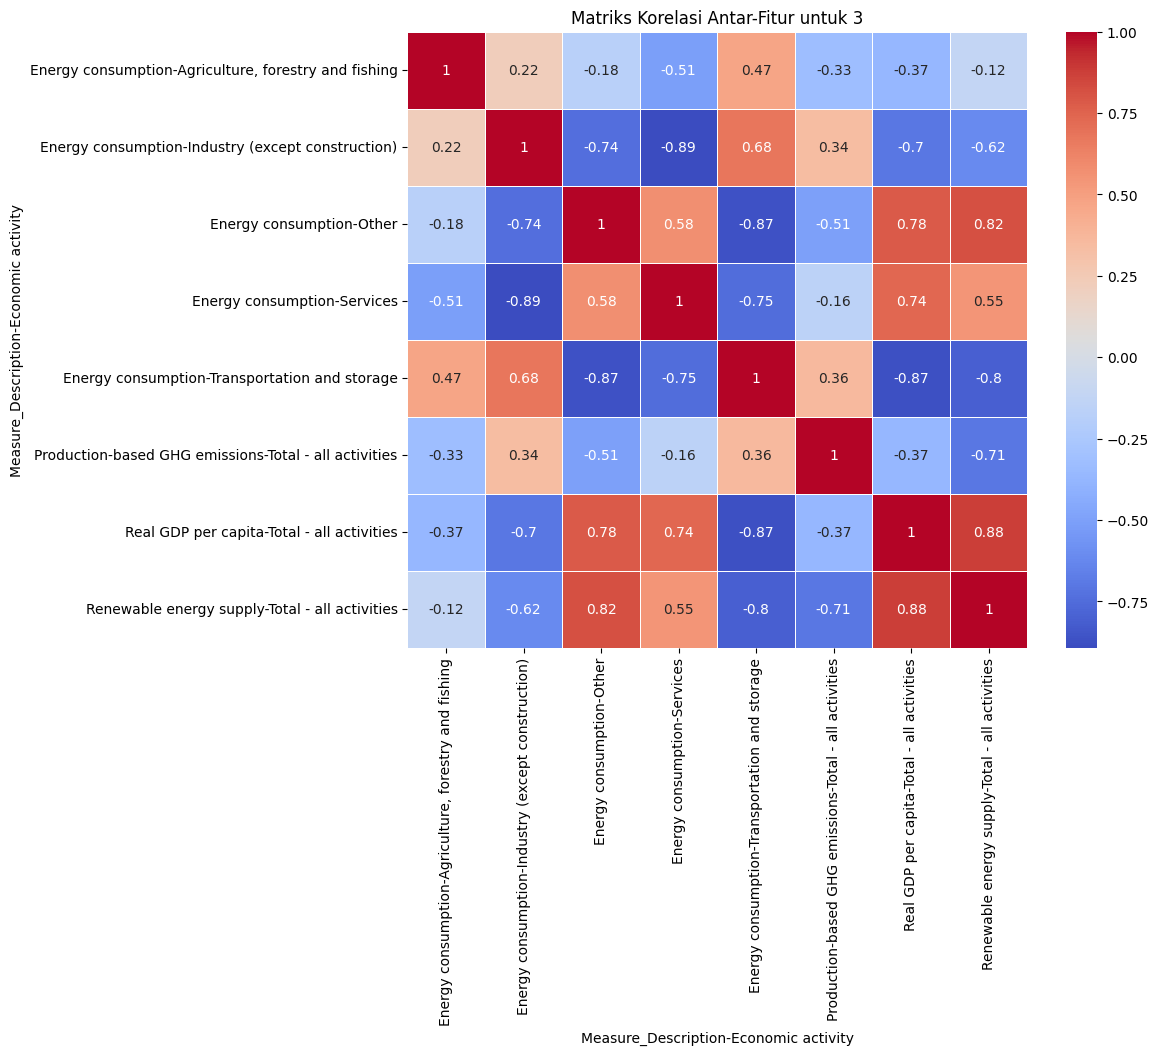

Matriks Korelasi untuk 4
Measure_Description                                                             Energy consumption  \
Economic activity                                                Agriculture, forestry and fishing   
Measure_Description            Economic activity                                                     
Energy consumption             Agriculture, forestry and fishing                          1.000000   
                               Industry (except construction)                            -0.850807   
                               Other                                                     -0.032324   
                               Services                                                   0.624412   
                               Transportation and storage                                 0.587225   
Production-based GHG emissions Total - all activities                                    -0.302229   
Real GDP per capita            Total - all activities    

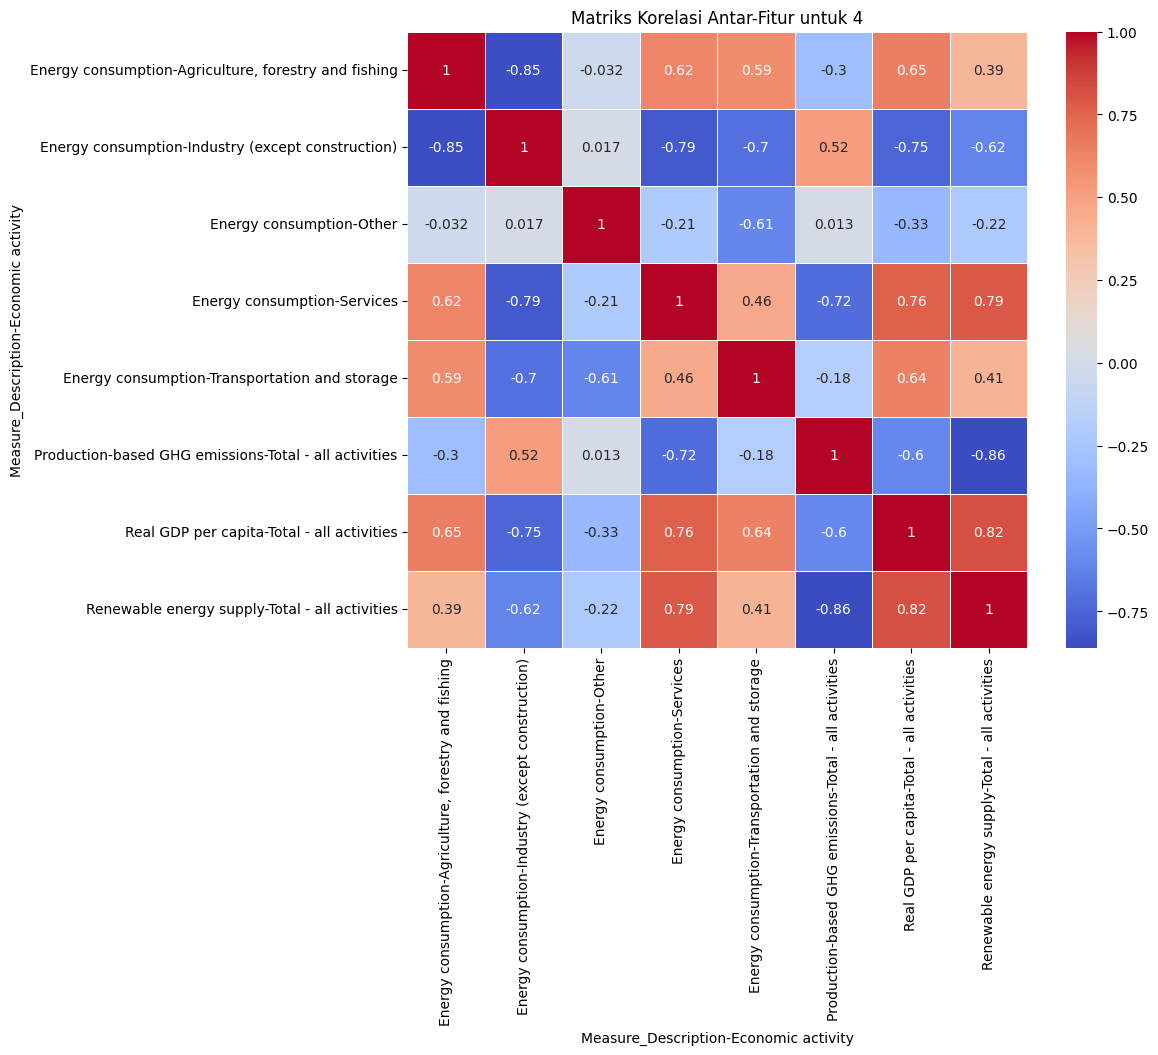

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daftar unik negara dalam dataset
countries = dataset_clean[('Country_Region', '')].unique()

# Loop untuk menghitung dan menampilkan matriks korelasi per negara
for country in countries:
    # Memfilter data untuk negara tertentu
    country_data = dataset_clean[dataset_clean[('Country_Region', '')] == country]

    # Memilih fitur numerik untuk negara tersebut
    numerical_features = country_data.select_dtypes(include=['float64']).columns
    correlation_matrix = country_data[numerical_features].corr()

    # Menampilkan matriks korelasi
    print(f"Matriks Korelasi untuk {country}")
    print(correlation_matrix)

    # Visualisasi matriks korelasi menggunakan heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Matriks Korelasi Antar-Fitur untuk {country}')
    plt.show()


Interpretasi:

Heatmap adalah visualisasi korelasi yang bisa memberikan gambaran atau dugaan awal mengenai hubungan antar variabelnya, namun diperlukan analisis lebih lanjut untuk insight lebih mendalam.
1. China
- Berdasarkan heatmap diatas GHG Emission di china berkorelasi tinggi dengan Real GDP per capita atau menunjukkan bahwa pertumbuhan ekonomi di China berjalan beriringan dengan bertambahnya emisi gas rumah kaca di negara tersebut.
- Sektor konsumsi energi pada sektor Transportasi menjadi sektor tertinggi yang berkorelasi atau berpengaruh teradap meningkatnya GHG Emission di negara tersebut.
- Sektor konsumsi energi pada sektor other atau bisa dibilang include sektor rumah tangga menjadi sektor yang berpengaruh terbalik dengan GHG Emission atau kenaikan konsumsi pada sektor ini tidak menyebabkan meningkatnya emisi gas rumah kaca.

2. Jerman
- Berdasarkan heatmap diatas GHG Emission di Jerman berkorelasi tinggi dengan Energy Consumption di sektor other (berbanding terbalik dengan china). Korelasi antara GHG Emission dan Real GDP disini memiliki korelasi yang tinggi namun berbalik nilai yang artinya kenaikan pertumbuhan ekonomi di negara ini tidak berpengaruh teradap meningkatnya GHG Emission.
- Efisiensi antara pertumbuhan ekonomi dan emisi gas rumah kaca di negara ini juga dibuktikan dengan variabel Renewable Energy atau energi terbarukan yang juga berbanding terbalik dengan GHG Emission yang bisa disimpulkan penggunaan energi terbarukan untuk sumber energi pada negara ini dapat membantu pengurangan emisi gas rumah kaca namun pertumbuhan ekonominya tetap berjalan.

3. Jepang
- Berdasarkan heatmap diatas GHG Emission di Jepang paling berkorelasi dengan energy consumption di sektor transport itupun bukan korelasi yang kuat.
- Sama seperti Jerman Korelasi antara GHG Emission dan Real GDP disini memiliki korelasi yang tinggi namun berbalik nilai yang artinya kenaikan pertumbuhan ekonomi di negara ini tidak berpengaruh teradap meningkatnya GHG Emission begitu pula dengan variabel Renewable Energynya yang juga berbanding terbalik dengan GHG Emission yang bisa disimpulkan penggunaan energi terbarukan untuk sumber energi pada negara ini dapat membantu pengurangan emisi gas rumah kaca namun pertumbuhan ekonominya tetap berjalan.

4. Amerika Serikat
- Berdasarkan heatmap diatas GHG Emission di Amerika paling berkorelasi dengan energy consumption di sektor industry itupun bukan korelasi yang kuat.
- Sama seperti Jerman dan Jepang Korelasi antara GHG Emission dan Real GDP disini memiliki korelasi yang tinggi namun berbalik nilai yang artinya kenaikan pertumbuhan ekonomi di negara ini tidak berpengaruh teradap meningkatnya GHG Emission begitu pula dengan variabel Renewable Energynya yang juga berbanding terbalik dengan GHG Emission yang bisa disimpulkan penggunaan energi terbarukan untuk sumber energi pada negara ini dapat membantu pengurangan emisi gas rumah kaca namun pertumbuhan ekonominya tetap berjalan.

5. Indonesia
- Berdasarkan heatmap diatas GHG Emission di Indonesia menunjukkan korelasi yang kuat hampir di setiap sektor terutama pada GDP per capita nya yang berkorelasi kuat dan searah yang menunjukkan bahwa meningkatnya pertumbuhan ekonomi di Indonesia berjalan beriringan dengan bertambahnya emisi gas rumah kaca di negara tersebut.
- Sektor konsumsi energi pada sektor Service menjadi sektor tertinggi yang berkorelasi atau berpengaruh teradap meningkatnya GHG Emission di negara tersebut.
- Variabel Renewable Energy di Indonesia juga menunjukkan korelasi kuat dan searah dengan GHG Emission total dan Real GDP per capita yang bisa menunjukkan bahwa penggunaan energy tebarukan belum efisien karena masih berpengaruh terhadap meningkatnya GHG Emission.

Dari gambaran awal kodisi kelima negara tersebut bisa menunjukkan pengaruh variabel satu sama lain seperti pentingnya Renewable Energy atau Energi Terbarukan yang bisa tetap meningkatkan GDP per Capita (Pertumbuhan Ekonomi) tanpa meningkatkan GHG Emission Total.

#C.3 Feature Engineering

Berdasarkan dataset yang sudah dianalisis, maka dibuat tiga fitur baru yang dibuat untuk mendukung analisis lebih mendalam terkait pertumbuhan ekonomi dan efisiensi energi. Fitur-fitur tersebut adalah sebagai berikut :

## 1.GDP Growth Rate

  Fitur ini akan menghitung tingkat pertumbuhan tahunan PDB per kapita untuk melacak perubahan ekonomi dari tahun ke tahun.

In [ ]:
# Menghitung GDP Growth Rate:

dataset_clean['GDP Growth Rate'] = (dataset_clean['Real GDP per capita'].diff() / dataset_clean['Real GDP per capita'].shift(1)) * 100

# Mengisi nilai kosong (nan) dengan 0
data = dataset_clean.fillna(0)

# Mengatur tampilan tabel dan mengatur numerik agar menampilkan 2 angka desimal desimal
styled_data = data.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).format(precision=2)

# Mencetak tabel
print("Tabel GDP Growth Rate")
print("")
styled_data

Tabel GDP Growth Rate



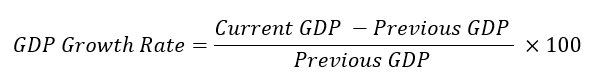

**Interpretasi:**

Fitur *GDP Growth Rate* mengukur laju pertumbuhan tahunan Produk Domestik Bruto (PDB) per kapita dalam bentuk persentase selama periode 1995-2020. Nilai positif dari fitur ini menunjukkan adanya pertumbuhan ekonomi, yang berarti ada peningkatan pendapatan rata-rata per individu. Sebaliknya, nilai negatif mengindikasikan kontraksi atau penurunan ekonomi.

   Dengan memantau *GDP Growth Rate*, kita dapat memahami fluktuasi pertumbuhan ekonomi dari waktu ke waktu. Hal ini memberikan gambaran umum tentang kesehatan ekonomi negara, apakah sedang berkembang, stagnan, atau bahkan mengalami kemunduran selama periode tersebut.

**Kesimpulan:**
- Jika nilai *GDP Growth Rate* cenderung positif dan stabil, ini menunjukkan bahwa ekonomi berkembang dengan baik. Hal ini bisa mengindikasikan peningkatan standar hidup, produktivitas, dan peluang ekonomi bagi penduduk.
- Jika *GDP Growth Rate* fluktuatif atau cenderung negatif, hal ini bisa menandakan adanya ketidakstabilan ekonomi. Faktor-faktor seperti krisis ekonomi, bencana alam, atau ketidakstabilan politik bisa menjadi penyebab utama fluktuasi tersebut.
- *GDP Growth Rate* dapat digunakan untuk membandingkan periode pertumbuhan yang kuat dengan periode resesi, sehingga membantu pengambil kebijakan dalam merumuskan strategi yang lebih baik untuk stabilisasi dan pertumbuhan ekonomi di masa mendatang.



## 2.Energy Intensity per GDP

  Fitur ini akan mengukur seberapa banyak energi yang dikonsumsi per unit PDB, memberikan wawasan terkait efisiensi energi dalam kaitannya dengan aktivitas ekonomi.


In [ ]:
# Menghitung Energy Intensity per GDP
dataset_clean['Energy Intensity per GDP'] = (
    dataset_clean[('Energy consumption', 'Agriculture, forestry and fishing')] +
    dataset_clean[('Energy consumption', 'Industry (except construction)')] +
    dataset_clean[('Energy consumption', 'Services')] +
    dataset_clean[('Energy consumption', 'Transportation and storage')] +
    dataset_clean[('Energy consumption', 'Other')]
    / dataset_clean[('Real GDP per capita', 'Total - all activities')])

# Mengisi nilai kosong (nan) dengan 0
data = dataset_clean.fillna(0)
dataset_clean = data

# Mengatur tampilan tabel dan mengatur numerik agar menampilkan 2 angka desimal
styled_data = dataset_clean.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).format(precision=2)

# Mencetak tabel
print("Tabel Energy Intensity per GDP")
print("")
styled_data

Tabel Energy Intensity per GDP



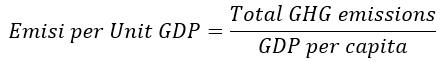

**Interpretasi:**

Fitur *Energy Intensity per GDP* mengukur jumlah konsumsi energi yang dibutuhkan untuk menghasilkan setiap unit Produk Domestik Bruto (PDB) selama periode 1995-2020. Fitur ini mencerminkan seberapa efisien energi digunakan dalam kegiatan ekonomi negara.

- Nilai yang lebih tinggi menunjukkan bahwa lebih banyak energi yang dikonsumsi untuk menghasilkan PDB, yang dapat menandakan bahwa sektor-sektor ekonomi seperti industri, transportasi, dan pertanian kurang efisien dalam menggunakan energi.
- Sebaliknya, nilai yang lebih rendah menunjukkan bahwa ekonomi lebih efisien dalam memanfaatkan energi untuk menciptakan output ekonomi.

Fitur ini penting untuk mengevaluasi efisiensi energi dan keberlanjutan ekonomi, terutama dalam menghadapi tantangan global terkait pengurangan emisi karbon dan peningkatan efisiensi energi.

##3.Renewable Energy Intensity per GDP
Fitur ini menghitung intensitas energi terbarukan per unit GDP. Ini berarti kita melihat seberapa besar pasokan energi terbarukan (dalam satuan energi) yang digunakan untuk setiap satu unit output ekonomi (GDP).

In [ ]:
# Menghitung Renewable Energy Intensity per GDP
dataset_clean['Renewable Energy Intensity per GDP'] = (
    dataset_clean[('Renewable energy supply', 'Total - all activities')] /
    dataset_clean[('Real GDP per capita', 'Total - all activities')]
)

# Mengisi nilai kosong (NaN) dengan 0
dataset_clean['Renewable Energy Intensity per GDP'] = dataset_clean['Renewable Energy Intensity per GDP'].fillna(0)

# Mengatur tampilan tabel dengan mencantumkan kolom Country_Region dan fitur baru
styled_data = dataset_clean[['Country_Region', 'Renewable Energy Intensity per GDP']].style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).format(precision=2)

# Menampilkan tabel
print("Tabel Renewable Energy Intensity per GDP per Negara")
display(styled_data)


Tabel Renewable Energy Intensity per GDP per Negara


Measure_Description,Country_Region,Renewable Energy Intensity per GDP
Economic activity,,
1,0,41158.33
5,0,30472.63
6,0,27951.67
7,0,25643.88
8,0,22764.58
9,0,20667.18
10,0,18624.39
11,0,16823.53
12,0,14406.15


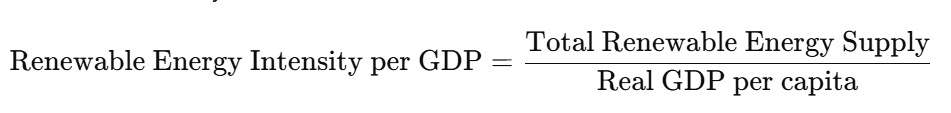

**Interpretasi:**

Fitur ini membantu kita memahami:

**Efisiensi Ekonomi Energi Terbarukan**: Menunjukkan seberapa efisien suatu negara memanfaatkan energi terbarukan untuk kegiatan ekonominya. Jika intensitasnya tinggi, artinya negara tersebut menggunakan banyak energi terbarukan per unit GDP, yang bisa berarti mereka mengandalkan energi bersih dalam ekonomi mereka.
**Potensi Peningkatan**: Negara dengan intensitas energi terbarukan rendah mungkin perlu mengembangkan lebih banyak energi terbarukan untuk mencapai target keberlanjutan.

Dengan menggunakan fitur ini, kita bisa mengetahui bagaimana sebuah negara memanfaatkan sumber daya energi bersih serta seberapa besar ketergantungan ekonomi pada energi terbarukan, yang dapat memengaruhi kebijakan pemerintah atau keputusan investasi dalam teknologi ramah lingkungan. Sehingga kita bisa membandingkan seberapa "hijau" atau berkelanjutannya sektor ekonomi antar negara atau antar tahun, yang memberikan wawasan tambahan dalam studi keberlanjutan dan lingkungan.

#**Assignment Chapter 3 : Machine Learning**

## 1.Menentukan machine learning model

Berdasarkan hasil diskusi yang telah dilakukan, diputuskan bahwa machine learning model yang akan digunakan adalah **supervised learning (regression)**. Pemilihan ini didasarkan pada karakteristik dataset serta problem understanding sebelumnya, di mana tujuan utama adalah memprediksi nilai berkelanjutan, yaitu efisiensi sektor berdasarkan produktivitas GHG. Model regresi dipilih karena masalah ini melibatkan prediksi nilai kontinu yang berkaitan dengan efisiensi sektor.

## 2.Alasan memilih machine learning model superviced learning (regression)

Pemilihan model supervised learning (regression) didasarkan pada beberapa point:

*   **Sifat data yang mengandung nilai kontinu**: Dalam kasus ini, target yang ingin diprediksi adalah produktivitas GHG atau efisiensi sektor, yang merupakan nilai numerik kontinu. Model regresi sesuai untuk menangani masalah prediksi nilai kontinu.
*   **Menyesuaikan label pada data**: Dataset yang digunakan memiliki variabel yang jelas, yaitu produktivitas GHG dan efisiensi setiap sektor, sehingga model supervised learning yang sesuai, di mana model dilatih menggunakan data berlabel.
*   **Menentukan hubungan antara variabel**: Tujuan utama adalah memahami hubungan antara fitur-fitur tertentu (seperti jenis sektor, konsumsi energi, dll.) dan efisiensi sektor. Model regresi memungkinkan identifikasi pola hubungan ini, baik itu hubungan linear atau non-linear, tergantung pada kompleksitas model yang dipilih (misalnya, Linear Regression atau Random Forest Regressor).

Dengan alasan-alasan diatas, model **supervised learning regression** dipilih sebagai pilihan terbaik untuk masalah prediksi efisiensi sektor berdasarkan produktivitas GHG.

## 3.Melakukan cross-validation

Machine Learning Model : **Superviced Learning (Regression)**

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

df = dataset_clean.copy()

# Define your features and target variable
X = df[[
    ('Real GDP per capita', 'Total - all activities'),
    ('Renewable energy supply', 'Total - all activities'),
    ('Energy consumption', 'Agriculture, forestry and fishing'),
    ('Energy consumption', 'Industry (except construction)'),
    ('Energy consumption', 'Other'),
    ('Energy consumption', 'Services'),
    ('Energy consumption', 'Transportation and storage')
]]

y = df[['Production-based GHG emissions']]

# Membagi data menjadi data latih dan data uji (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat list untuk menyimpan hasil
results = []

# Fungsi untuk evaluasi model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((model_name, mae, rmse, r2))
    print(f"{model_name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate_model(lr, X_test, y_test, "Linear Regression")

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
evaluate_model(ridge, X_test, y_test, "Ridge Regression")

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
evaluate_model(lasso, X_test, y_test, "Lasso Regression")

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.values.ravel())  # Menggunakan ravel untuk mengubah y_train ke 1D
evaluate_model(rf, X_test, y_test, "Random Forest")

# Menampilkan hasil
result_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print("\nHasil evaluasi model:")
print(result_df)

Linear Regression: MAE=373.20, RMSE=502.73, R²=0.93
Ridge Regression: MAE=365.77, RMSE=498.12, R²=0.93
Lasso Regression: MAE=365.54, RMSE=497.76, R²=0.93


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.8647e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.415e+07, tolerance: 2.742e+04
  model = cd_fast.enet_coordinate_descent(


Random Forest: MAE=131.33, RMSE=286.62, R²=0.98

Hasil evaluasi model:
               Model         MAE        RMSE        R²
0  Linear Regression  373.200356  502.732470  0.926171
1   Ridge Regression  365.768021  498.118352  0.927520
2   Lasso Regression  365.539152  497.761089  0.927624
3      Random Forest  131.334680  286.622207  0.976002


In [ ]:
# Import library yang diperlukan untuk cross-validation Linier Regression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Fungsi evaluasi model untuk MAE, RMSE, dan R²
def cross_val_metrics(model, X, y, cv=5):
    # K-Fold Cross-Validation
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    # Scorer untuk MAE, RMSE, dan R²
    mae_scorer = make_scorer(mean_absolute_error)
    rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
    r2_scorer = make_scorer(r2_score)

    # Menghitung skor cross-validation untuk setiap metrik
    mae_scores = cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)
    rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

    print("Linier Regression :\n")

    # Menampilkan hasil evaluasi untuk setiap fold
    print("MAE scores on each fold:", mae_scores)
    print("Mean MAE score:", np.mean(mae_scores))
    print("MAE std deviation:", np.std(mae_scores))

    print("\nRMSE scores on each fold:", rmse_scores)
    print("Mean RMSE score:", np.mean(rmse_scores))
    print("RMSE std deviation:", np.std(rmse_scores))

    print("\nR² scores on each fold:", r2_scores)
    print("Mean R² score:", np.mean(r2_scores))
    print("R² std deviation:", np.std(r2_scores))

    return {
        'MAE': mae_scores,
        'RMSE': rmse_scores,
        'R²': r2_scores
    }

# Pemodelan Linear Regression
linier_regressor = LinearRegression()

# Melakukan evaluasi cross-validation
results = cross_val_metrics(linier_regressor, X, y, cv=5)


Linier Regression :

MAE scores on each fold: [373.2003564  458.15027532 530.05024294 339.18665305 581.29894277]
Mean MAE score: 456.3772940950128
MAE std deviation: 91.31080382479041

RMSE scores on each fold: [502.7324696  546.88726084 652.439672   440.44614931 692.66693604]
Mean RMSE score: 567.0344975580523
RMSE std deviation: 93.42678981780044

R² scores on each fold: [0.9261707  0.89186089 0.87409833 0.85716621 0.83261287]
Mean R² score: 0.8763817972852859
R² std deviation: 0.0316503067248845


In [ ]:
# Import library yang diperlukan untuk Ridge Regression
from sklearn.linear_model import Ridge

# Fungsi evaluasi model untuk MAE, RMSE, dan R² pada Ridge Regression
def cross_val_metrics_ridge(model, X, y, cv=5):
    # K-Fold Cross-Validation
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    # Scorer untuk MAE, RMSE, dan R²
    mae_scorer = make_scorer(mean_absolute_error)
    rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
    r2_scorer = make_scorer(r2_score)

    # Menghitung skor cross-validation untuk setiap metrik
    mae_scores = cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)
    rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

    print("Ridge Regression :\n")

    # Menampilkan hasil evaluasi untuk setiap fold
    print("MAE scores on each fold:", mae_scores)
    print("Mean MAE score:", np.mean(mae_scores))
    print("MAE std deviation:", np.std(mae_scores))

    print("\nRMSE scores on each fold:", rmse_scores)
    print("Mean RMSE score:", np.mean(rmse_scores))
    print("RMSE std deviation:", np.std(rmse_scores))

    print("\nR² scores on each fold:", r2_scores)
    print("Mean R² score:", np.mean(r2_scores))
    print("R² std deviation:", np.std(r2_scores))

    return {
        'MAE': mae_scores,
        'RMSE': rmse_scores,
        'R²': r2_scores
    }

# Pemodelan Ridge Regression dengan alpha=1.0
ridge_regressor = Ridge(alpha=1.0)

# Melakukan evaluasi cross-validation pada Ridge Regression
ridge_results = cross_val_metrics_ridge(ridge_regressor, X, y, cv=5)


Ridge Regression :

MAE scores on each fold: [365.76802071 461.39956422 499.89136064 336.04985933 577.30894561]
Mean MAE score: 448.0835501025029
MAE std deviation: 88.1906599993432

RMSE scores on each fold: [498.1183517  549.56263    620.14781613 444.53595017 686.54355994]
Mean RMSE score: 559.7816615897893
RMSE std deviation: 85.90811123645945

R² scores on each fold: [0.9275197  0.89080027 0.88625267 0.8545013  0.83555929]
Mean R² score: 0.8789266448959863
R² std deviation: 0.03172779277506102


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.8647e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.96532e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.48962e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.61164e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning

In [ ]:
# Import library yang diperlukan untuk Lasso Regression
from sklearn.linear_model import Lasso

# Fungsi evaluasi model untuk MAE, RMSE, dan R² pada Lasso Regression
def cross_val_metrics_lasso(model, X, y, cv=5):
    # K-Fold Cross-Validation
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    # Scorer untuk MAE, RMSE, dan R²
    mae_scorer = make_scorer(mean_absolute_error)
    rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
    r2_scorer = make_scorer(r2_score)

    # Menghitung skor cross-validation untuk setiap metrik
    mae_scores = cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)
    rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

    print("Lasso Regression :\n")

    # Menampilkan hasil evaluasi untuk setiap fold
    print("MAE scores on each fold:", mae_scores)
    print("Mean MAE score:", np.mean(mae_scores))
    print("MAE std deviation:", np.std(mae_scores))

    print("\nRMSE scores on each fold:", rmse_scores)
    print("Mean RMSE score:", np.mean(rmse_scores))
    print("RMSE std deviation:", np.std(rmse_scores))

    print("\nR² scores on each fold:", r2_scores)
    print("Mean R² score:", np.mean(r2_scores))
    print("R² std deviation:", np.std(r2_scores))

    return {
        'MAE': mae_scores,
        'RMSE': rmse_scores,
        'R²': r2_scores
    }

# Pemodelan Lasso Regression dengan alpha=1.0
lasso_regressor = Lasso(alpha=1.0)

# Melakukan evaluasi cross-validation pada Lasso Regression
lasso_results = cross_val_metrics_lasso(lasso_regressor, X, y, cv=5)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.409e+07, tolerance: 2.742e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.336e+07, tolerance: 2.900e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.272e+07, tolerance: 2.710e

Lasso Regression :

MAE scores on each fold: [365.97276075 461.41773663 501.48212842 335.7579185  577.13571164]
Mean MAE score: 448.3532511849686
MAE std deviation: 88.36575653985604

RMSE scores on each fold: [498.44369934 549.73190619 622.37432879 444.28930259 686.71765799]
Mean RMSE score: 560.3113789797977
RMSE std deviation: 86.29138352279443

R² scores on each fold: [0.92742499 0.89073299 0.88543443 0.85466271 0.83547588]
Mean R² score: 0.8787461988295557
R² std deviation: 0.03165556971051118


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.475e+07, tolerance: 3.159e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.156e+07, tolerance: 2.870e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.409e+07, tolerance: 2.742e

In [ ]:
# Import library yang diperlukan untuk Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

# Fungsi evaluasi model untuk MAE, RMSE, dan R² pada Random Forest Regression
def cross_val_metrics_rf(model, X, y, cv=5):
    # K-Fold Cross-Validation
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    # Scorer untuk MAE, RMSE, dan R²
    mae_scorer = make_scorer(mean_absolute_error)
    rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
    r2_scorer = make_scorer(r2_score)

    # Menghitung skor cross-validation untuk setiap metrik
    mae_scores = cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)
    rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

    print("\nRandom Forest :\n")

    # Menampilkan hasil evaluasi untuk setiap fold
    print("MAE scores on each fold:", mae_scores)
    print("Mean MAE score:", np.mean(mae_scores))
    print("MAE std deviation:", np.std(mae_scores))

    print("\nRMSE scores on each fold:", rmse_scores)
    print("Mean RMSE score:", np.mean(rmse_scores))
    print("RMSE std deviation:", np.std(rmse_scores))

    print("\nR² scores on each fold:", r2_scores)
    print("Mean R² score:", np.mean(r2_scores))
    print("R² std deviation:", np.std(r2_scores))

    return {
        'MAE': mae_scores,
        'RMSE': rmse_scores,
        'R²': r2_scores
    }

# Pemodelan Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Melakukan evaluasi cross-validation pada Random Forest Regression
rf_results = cross_val_metrics_rf(rf_regressor, X, y, cv=5)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi


Random Forest :

MAE scores on each fold: [127.298584  57.398642  84.045228  39.418014 109.36942 ]
Mean MAE score: 83.5059775999999
MAE std deviation: 32.28728023728003

RMSE scores on each fold: [280.73571657 120.18185665 187.56147004  97.26916405 191.35032218]
Mean RMSE score: 175.4197058986937
RMSE std deviation: 64.26724866665734

R² scores on each fold: [0.97697762 0.99477766 0.9895951  0.9930338  0.98722586]
Mean R² score: 0.9883220091510191
R² std deviation: 0.006251302512899647


## 4.Menjelaskan hasil dari cross-validation basic


Berikut ini penjelasan untuk hasil Cross Validation dari setiap regression yang dilakukan

**Linear Regression** :

1. **MAE (Mean Absolute Error)**:
   - **Nilai MAE untuk setiap fold**: [373.20, 458.15, 530.05, 339.19, 581.30]
   - **Rata-rata MAE**: 456.38
   - **Standar deviasi MAE**: 91.31

   **Interpretasi**:
   - MAE mengukur rata-rata perbedaan absolut antara nilai sebenarnya dan nilai prediksi. Nilai MAE pada setiap fold berkisar antara 339 hingga 581, menunjukkan bahwa tingkat kesalahan prediksi bervariasi antar fold namun masih berada dalam rentang yang relatif konsisten. Rata-rata MAE sebesar 456.38 menunjukkan bahwa secara keseluruhan model membuat kesalahan rata-rata sebesar 456. Standar deviasi 91.31 menunjukkan bahwa kesalahan pada setiap fold cukup konsisten.

2. **RMSE (Root Mean Squared Error)**:
   - **Nilai RMSE untuk setiap fold**: [502.73, 546.89, 652.44, 440.45, 692.67]
   - **Rata-rata RMSE**: 567.03
   - **Standar deviasi RMSE**: 93.43

   **Interpretasi**:
   - RMSE, yang lebih sensitif terhadap outlier dibandingkan MAE, menunjukkan nilai kesalahan yang sedikit lebih tinggi karena mempertimbangkan kuadrat dari kesalahan. Rata-rata RMSE sebesar 567.03 menunjukkan bahwa prediksi model memiliki kesalahan rata-rata sekitar 567 saat memperhitungkan outlier. Standar deviasi 93.43 menunjukkan bahwa performa model di setiap fold cukup konsisten.

3. **R² (R-Squared)**:
   - **Nilai R² untuk setiap fold**: [0.9262, 0.8919, 0.8741, 0.8572, 0.8326]
   - **Rata-rata R²**: 0.8764
   - **Standar deviasi R²**: 0.0317

   **Interpretasi**:
   - R² mengukur seberapa baik model dapat menjelaskan variasi dalam data target. Rata-rata R² sebesar 0.8764 menunjukkan bahwa sekitar 88% variasi dalam data target dapat dijelaskan oleh model. Ini menunjukkan performa yang cukup baik, dengan standar deviasi sebesar 0.0317 yang menunjukkan bahwa kemampuan model dalam menjelaskan variabilitas data pada setiap fold cukup stabil.

**Ridge Regression** :

1. **MAE (Mean Absolute Error)**:
   - **Nilai MAE untuk setiap fold**: [365.77, 461.40, 499.89, 336.05, 577.31]
   - **Rata-rata MAE**: 448.08
   - **Standar deviasi MAE**: 88.19

   **Interpretasi**:
   - MAE mengukur rata-rata kesalahan absolut antara prediksi dan nilai sebenarnya. Dengan rata-rata MAE sebesar 448.08, model Ridge Regression menghasilkan kesalahan prediksi yang sedikit lebih rendah dibandingkan hasil dari Linear Regression sebelumnya, yang memiliki rata-rata MAE 456.38. Ridge Regression memberikan hasil yang sedikit lebih baik dalam mengurangi kesalahan absolut, meskipun nilai rata-rata kesalahan masih cukup tinggi. Standar deviasi sebesar 88.19 menunjukkan bahwa kesalahan antar fold memiliki variasi yang moderat namun tetap konsisten.

2. **RMSE (Root Mean Squared Error)**:
   - **Nilai RMSE untuk setiap fold**: [498.12, 549.56, 620.15, 444.54, 686.54]
   - **Rata-rata RMSE**: 559.78
   - **Standar deviasi RMSE**: 85.91

   **Interpretasi**:
   - RMSE, yang lebih sensitif terhadap outlier dibandingkan MAE, menunjukkan nilai kesalahan kuadrat rata-rata sebesar 559.78. Ini sedikit lebih rendah daripada RMSE pada model Linear Regression (567.03), menunjukkan bahwa penggunaan Ridge Regression membantu mengurangi dampak outlier dan meningkatkan stabilitas model. Standar deviasi RMSE sebesar 85.91 menunjukkan bahwa variasi performa antar fold relatif kecil dan cukup stabil.

3. **R² (R-Squared)**:
   - **Nilai R² untuk setiap fold**: [0.9275, 0.8908, 0.8863, 0.8545, 0.8356]
   - **Rata-rata R²**: 0.8789
   - **Standar deviasi R²**: 0.0317

   **Interpretasi**:
   - R² mengukur seberapa baik model menjelaskan variasi dalam data target. Rata-rata R² sebesar 0.8789 menunjukkan bahwa Ridge Regression menjelaskan sekitar 88% variabilitas dalam data target, mirip dengan hasil Linear Regression (0.8764). Ini menunjukkan bahwa Ridge Regression memberikan hasil yang sebanding dalam hal penjelasan variabilitas data. Standar deviasi sebesar 0.0317 menunjukkan variasi performa antar fold yang kecil, mencerminkan stabilitas model.

**Lasso Regression**:

1. **MAE (Mean Absolute Error)**:
   - **Nilai MAE untuk setiap fold**: [365.97, 461.42, 501.48, 335.76, 577.14]
   - **Rata-rata MAE**: 448.35
   - **Standar deviasi MAE**: 88.37

   **Interpretasi**:
   - MAE mengukur rata-rata kesalahan absolut antara prediksi dan nilai sebenarnya. Dengan rata-rata MAE sebesar 448.35, Lasso Regression menghasilkan kesalahan absolut yang hampir sama dengan Ridge Regression (448.08) dan sedikit lebih rendah dibandingkan Linear Regression (456.38). Ini menunjukkan bahwa Lasso Regression memberikan tingkat kesalahan yang relatif stabil dalam hal kesalahan absolut. Standar deviasi sebesar 88.37 menunjukkan bahwa variasi kesalahan antar fold masih berada dalam kisaran yang cukup konsisten.

2. **RMSE (Root Mean Squared Error)**:
   - **Nilai RMSE untuk setiap fold**: [498.44, 549.73, 622.37, 444.29, 686.72]
   - **Rata-rata RMSE**: 560.31
   - **Standar deviasi RMSE**: 86.29

   **Interpretasi**:
   - RMSE, yang lebih sensitif terhadap outlier, menunjukkan nilai rata-rata sebesar 560.31. Ini sedikit lebih rendah dibandingkan dengan hasil dari Linear Regression (567.03), tetapi hampir setara dengan Ridge Regression (559.78). Standar deviasi sebesar 86.29 menunjukkan bahwa variasi performa antar fold cukup kecil, menandakan bahwa model memiliki konsistensi yang baik di berbagai subset data.

3. **R² (R-Squared)**:
   - **Nilai R² untuk setiap fold**: [0.9274, 0.8907, 0.8854, 0.8547, 0.8355]
   - **Rata-rata R²**: 0.8787
   - **Standar deviasi R²**: 0.0317

   **Interpretasi**:
   - R² mengukur seberapa baik model menjelaskan variasi dalam data target. Dengan rata-rata R² sebesar 0.8787, Lasso Regression menjelaskan sekitar 88% variabilitas dalam data target, hasil yang sebanding dengan Ridge Regression (0.8789) dan sedikit lebih baik daripada Linear Regression (0.8764). Ini menunjukkan bahwa Lasso Regression memiliki performa yang cukup baik dalam menjelaskan variasi data. Standar deviasi R² sebesar 0.0317 menunjukkan bahwa model konsisten dalam menjelaskan variabilitas data pada setiap fold.

**Random Forest Regression** :

1. **MAE (Mean Absolute Error)**:
   - **Nilai MAE untuk setiap fold**: [127.30, 57.40, 84.05, 39.42, 109.37]
   - **Rata-rata MAE**: 83.51
   - **Standar deviasi MAE**: 32.29

   **Interpretasi**:
   - MAE mengukur rata-rata kesalahan absolut antara nilai prediksi dan nilai aktual. Dengan rata-rata MAE sebesar 83.51, Random Forest Regression menunjukkan kesalahan absolut yang jauh lebih rendah dibandingkan regresi lain dalam eksperimen ini. Standar deviasi sebesar 32.29 mengindikasikan bahwa variasi antar fold cukup besar, yang menunjukkan perbedaan performa model tergantung pada subset data yang digunakan.

2. **RMSE (Root Mean Squared Error)**:
   - **Nilai RMSE untuk setiap fold**: [280.74, 120.18, 187.56, 97.27, 191.35]
   - **Rata-rata RMSE**: 175.42
   - **Standar deviasi RMSE**: 64.27

   **Interpretasi**:
   - RMSE menunjukkan sensitivitas model terhadap outlier. Dengan rata-rata RMSE sebesar 175.42, Random Forest Regression menunjukkan performa yang cukup baik dalam meminimalkan kesalahan kuadrat. Standar deviasi sebesar 64.27 menunjukkan adanya variasi yang cukup besar dalam performa antar fold, menandakan bahwa performa model sedikit tergantung pada data yang digunakan pada setiap fold.

3. **R² (R-Squared)**:
   - **Nilai R² untuk setiap fold**: [0.9770, 0.9948, 0.9896, 0.9930, 0.9872]
   - **Rata-rata R²**: 0.9883
   - **Standar deviasi R²**: 0.0063

   **Interpretasi**:
   - R² mengukur seberapa baik model menjelaskan variasi dalam data target. Dengan rata-rata R² sebesar 0.9883, Random Forest Regression menjelaskan sekitar 99% dari variabilitas dalam data target, hasil yang sangat baik dan lebih tinggi dibandingkan model regresi lain. Standar deviasi sebesar 0.0063 menunjukkan variasi yang sangat kecil dalam performa antar fold, yang mengindikasikan bahwa model cukup konsisten dalam menjelaskan variasi data pada setiap fold.

## 5.Menerapkan learning curves dari machine learning model yang telah dibuat sebelumnya serta membuat visualisasi hasil dari learning curves


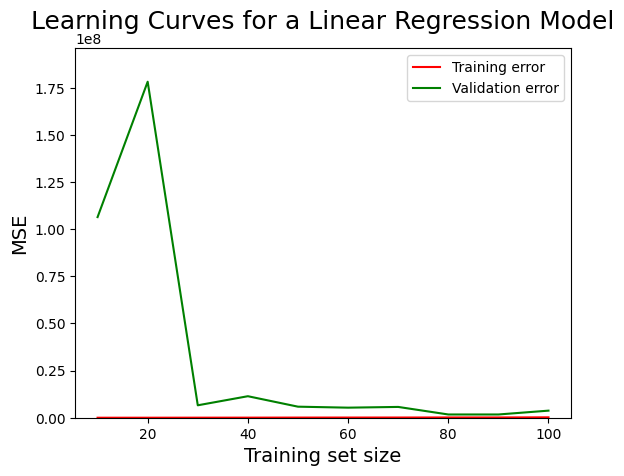

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression

# Pemodelan Linear Regression
regressor = LinearRegression()

# Menghitung learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    regressor, X, y, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Menghitung rata-rata dan standar deviasi untuk training dan validation scores
train_scores_mean = -np.mean(train_scores, axis=1)
validation_scores_mean = -np.mean(validation_scores, axis=1)

# Plotting Learning Curves
plt.style.use('default')

plt.plot(train_sizes, train_scores_mean, label='Training error', color='r')
plt.plot(train_sizes, validation_scores_mean, label='Validation error', color='g')

plt.ylabel('MSE', fontsize=14)
plt.xlabel('Training set size', fontsize=14)
plt.title('Learning Curves for a Linear Regression Model', fontsize=18, y=1.03)
plt.legend()
plt.ylim(0, max(max(train_scores_mean), max(validation_scores_mean)) * 1.1)

plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=9.55772e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.40767e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.94234e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.31784e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarnin

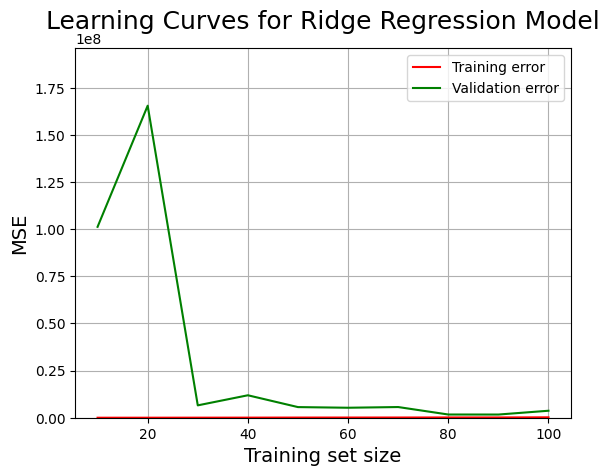

In [ ]:
# Fungsi untuk membuat learning curve
def plot_learning_curve_ridge(model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    # Menghitung training dan validation scores menggunakan learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring='neg_mean_squared_error', train_sizes=train_sizes, random_state=42
    )

    # Menghitung rata-rata dan standar deviasi untuk training dan validation scores
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    # Membuat plot
    plt.style.use('default')

    plt.plot(train_sizes, train_scores_mean, label='Training error', color='r')
    plt.plot(train_sizes, val_scores_mean, label='Validation error', color='g')


    # Label dan judul
    plt.ylabel('MSE', fontsize=14)
    plt.xlabel('Training set size', fontsize=14)
    plt.title('Learning Curves for Ridge Regression Model', fontsize=18, y=1.03)
    plt.legend()
    plt.ylim(0, max(max(train_scores_mean), max(validation_scores_mean)) * 1.1)
    plt.grid()
    plt.show()

# Membuat learning curves untuk Ridge Regression dengan alpha=1.0
plot_learning_curve_ridge(ridge_regressor, X, y, cv=5)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.732e+01, tolerance: 1.156e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.042e+03, tolerance: 4.343e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.987e+03, tolerance: 4.932e

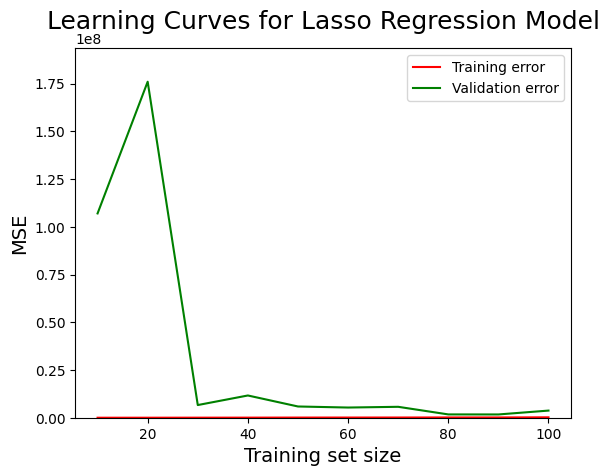

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Lasso

# Misalkan X dan y adalah data fitur dan target Anda
# Pemodelan Lasso Regression
lasso_regressor = Lasso(alpha=0.1)

# Menghitung learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    lasso_regressor, X, y.values.ravel(), cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Menghitung rata-rata dan standar deviasi untuk training dan validation scores
train_scores_mean = -np.mean(train_scores, axis=1)
validation_scores_mean = -np.mean(validation_scores, axis=1)

# Plotting Learning Curves
plt.style.use('default')

plt.plot(train_sizes, train_scores_mean, label='Training error', color='r')
plt.plot(train_sizes, validation_scores_mean, label='Validation error', color='g')

plt.ylabel('MSE', fontsize=14)
plt.xlabel('Training set size', fontsize=14)
plt.title('Learning Curves for Lasso Regression Model', fontsize=18, y=1.03)
plt.legend()
plt.ylim(0, np.max([train_scores_mean.max(), validation_scores_mean.max()]) * 1.1)

plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

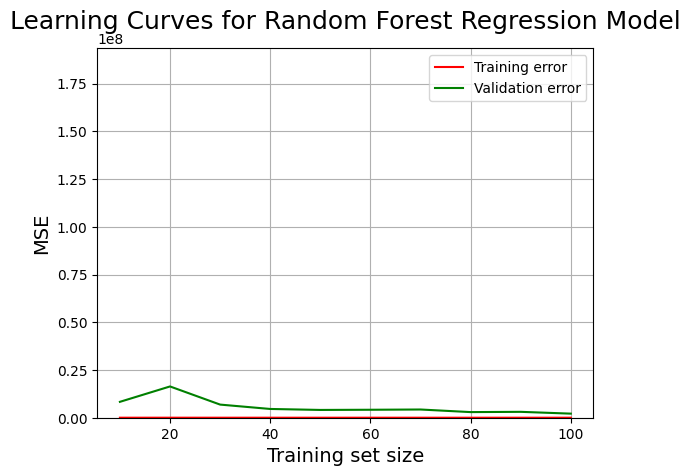

In [ ]:
# Fungsi untuk membuat learning curve
def plot_learning_curve_rf(model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    # Menghitung training dan validation scores menggunakan learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring='neg_mean_squared_error', train_sizes=train_sizes, random_state=42
    )

    # Menghitung rata-rata dan standar deviasi untuk training dan validation scores
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    # Membuat plot
    plt.style.use('default')

    plt.plot(train_sizes, train_scores_mean, label='Training error', color='r')
    plt.plot(train_sizes, val_scores_mean, label='Validation error', color='g')

    # Label dan judul
    plt.ylabel('MSE', fontsize=14)
    plt.xlabel('Training set size', fontsize=14)
    plt.title('Learning Curves for Random Forest Regression Model', fontsize=18, y=1.03)
    plt.legend()
    plt.ylim(0, np.max([train_scores_mean.max(), validation_scores_mean.max()]) * 1.1)
    plt.grid()
    plt.show()

# Membuat learning curves untuk Random Forest Regression
plot_learning_curve_rf(rf_regressor, X, y, cv=5)


## 6.Menjelaskan hasil dari visualisasi learning curves

Berikut adalah interpretasi dari learning curve yag sudah dibuat :
*   **Linear Regression**

Pada training error terlihat garis hampir mendekati nol pada sepanjang grafik yang berarti model memiliki performa sangat baik pada data training. Pada validation error, pada awalnya garis menunjukkan fluktuatif yang menunjukkan bahwa dengan sedikit data training, model tidak dapat menggeneralisasi dengan baik sehingga validasi error lebih tinggi. Namun, seiring bertambahnya data training, MSE pada set validasi stabil dan menurun yang menunjukkan bahwa model semakin dapat menggeneralisasi dengan baik.
* **Ridge Regression**

Sama seperti linear regression, training error hampir mendekati nol sepanjang grafik, menunjukkan bahwa model sangat akurat dalam pelatihan.Validation error pada grafik ini sedikit fluktuatif pada ukuran set pelatihan kecil, tetapi berfluktuasi lebih sedikit dibandingkan grafik sebelumnya. Ini menunjukkan bahwa model Ridge Regression sedikit lebih stabil dalam hal generalisasi dibandingkan model regresi linear.
* **Lasso Regression**

Secara keseluruhan, Lasso Regression dalam grafik ini menunjukkan bahwa meskipun pada awalnya validation error tinggi, model akhirnya berhasil melakukan generalisasi dengan baik, terutama setelah mendapatkan lebih banyak data pelatihan.
* **Random Forest Regression**

Random Forest Regression dalam grafik ini menunjukkan performa yang sangat baik pada data pelatihan. Secara keseluruhan, model memiliki performa generalisasi yang stabil dengan validation error yang relatif rendah dan tidak fluktuatif.

Dari interpretasi 4 grafik learning curve diatas, kelompok kami memilih Random Forest Regression sebagai model machine learning yang akan kami gunakan. Dilihat dari grafik yang ada, validation error pada Random Forest Regression jauh lebih rendah dan stabil dibandingkan model sebelumnya, yang menunjukkan bahwa model ini dapat menggeneralisasi dengan baik bahkan dengan data yang sedikit.


## 7.Melakukan eksekusi coding machine learning model

Berikut ini adalah eksekusi coding machine learning model superviced learning dengan menggunakan dataset yang sama dengan assigment chapter sebelumnya.


In [ ]:
dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 1 to 129
Data columns (total 13 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   (Country_Region, )                                        125 non-null    int64  
 1   (Year, )                                                  125 non-null    int64  
 2   (Energy consumption, Agriculture, forestry and fishing)   125 non-null    float64
 3   (Energy consumption, Industry (except construction))      125 non-null    float64
 4   (Energy consumption, Other)                               125 non-null    float64
 5   (Energy consumption, Services)                            125 non-null    float64
 6   (Energy consumption, Transportation and storage)          125 non-null    float64
 7   (Production-based GHG emissions, Total - all activities)  125 non-null    float64
 8   (Real GDP per capita, Tot

In [ ]:
print(dataset_clean.columns)

MultiIndex([(                    'Country_Region', ...),
            (                              'Year', ...),
            (                'Energy consumption', ...),
            (                'Energy consumption', ...),
            (                'Energy consumption', ...),
            (                'Energy consumption', ...),
            (                'Energy consumption', ...),
            (    'Production-based GHG emissions', ...),
            (               'Real GDP per capita', ...),
            (           'Renewable energy supply', ...),
            (                   'GDP Growth Rate', ...),
            (          'Energy Intensity per GDP', ...),
            ('Renewable Energy Intensity per GDP', ...)],
           names=['Measure_Description', 'Economic activity'])


In [ ]:
from sklearn.ensemble import RandomForestRegressor  # Untuk regresi
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

In [ ]:
# Menentukan variabel X dan Y
X = dataset_clean[[
    ('Real GDP per capita', 'Total - all activities'),
    ('Renewable energy supply', 'Total - all activities'),
    ('Energy consumption', 'Agriculture, forestry and fishing'),
    ('Energy consumption', 'Industry (except construction)'),
    ('Energy consumption', 'Other'),
    ('Energy consumption', 'Services'),
    ('Energy consumption', 'Transportation and storage')
]]

y = dataset_clean[['Production-based GHG emissions']]

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Inisialisasi Random Forest untuk regresi
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit model ke data training
model.fit(X_train, y_train.values.ravel())

RandomForestRegressor(random_state=42)

Interpretasi:
- **Tujuan Model**: Model ini bertujuan memprediksi emisi GHG berbasis produksi berdasarkan variabel-variabelekonomi dan konsumsi energi dari sektor-sektor spesifik, seperti konsumsi energi di sektor pertanian, industri, jasa, dan transportasi, serta suplai energi terbarukan dan GDP per capita.
- **Keuntungan Model Random Forest**: Model Random Forest efektif dalam menangkap pola non-linear dan hubungan kompleks antar variabel, seperti hubungan antara GDP per capita dan konsumsi energi di berbagai sektor terhadap emisi GHG. Dengan 100 random forest, model ini mampu membuat prediksi yang akurat dengan memperhitungkan variasi antar sektor dan mengurangi kemungkinan overfitting
- **Langkah Berikutnya**: Setelah Setelah model dilatih pada data training, tahap evaluasi dilakukan menggunakan data testing (X_test dan y_test) untuk mengukur seberapa baik model memprediksi emisi GHG pada data yang belum dilihat. Metrik seperti Mean Absolute Error (MAE) atau Mean Squared Error (MSE) dapat digunakan untuk menilai akurasi dan stabilitas prediksi model.

Feature Importance Scores:
                                             Feature  Importance
0    Renewable energy supply, Total - all activities    0.895651
1  Energy consumption, Industry (except construct...    0.080681
2        Real GDP per capita, Total - all activities    0.005808
3                          Energy consumption, Other    0.005711
4     Energy consumption, Transportation and storage    0.005066
5                       Energy consumption, Services    0.004486
6  Energy consumption, Agriculture, forestry and ...    0.002597


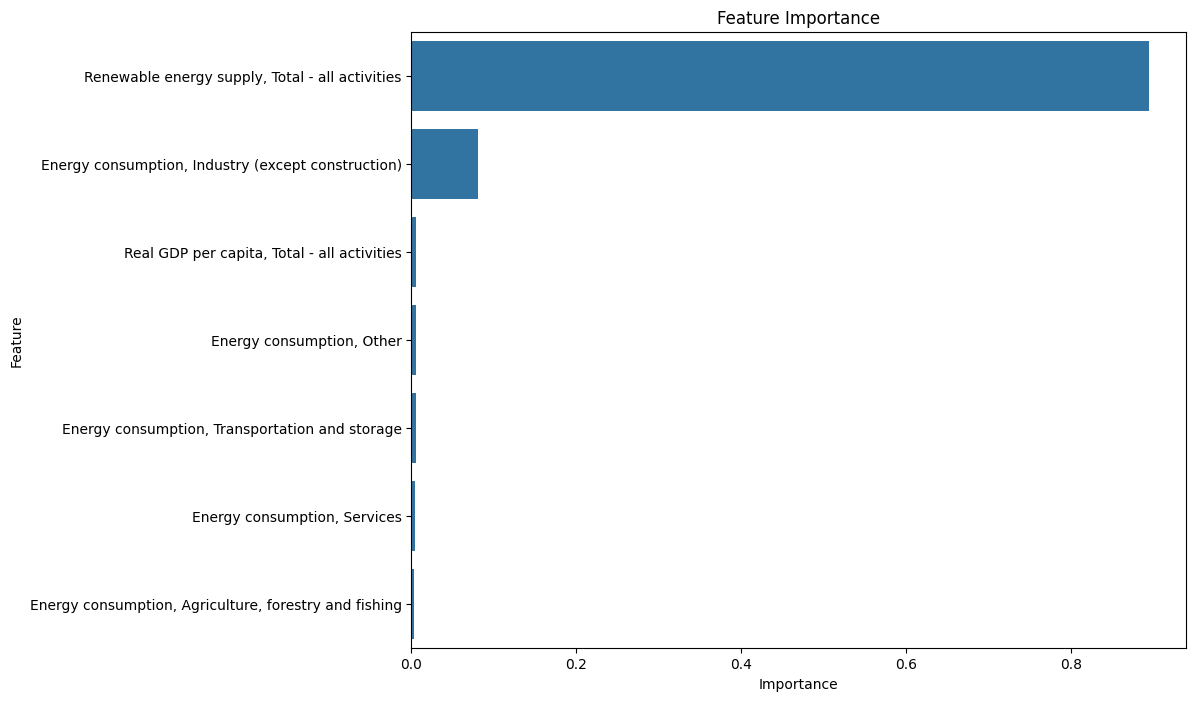

In [ ]:
# Get feature importances from the model
feature_importances = model.feature_importances_

# Get feature names from the DataFrame
# Convert the MultiIndex to a list of tuples
features = list(X_train.columns)

# Convert tuples to strings for better visualization
features = [', '.join(feature) for feature in features]

# Create a DataFrame to hold feature names and their importance scores
importances_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the DataFrame by the 'Importance' column in descending order
importances_df = importances_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the feature importance scores
print("Feature Importance Scores:")
print(importances_df)

# Visualization of Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importances_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 8.Memperbaiki akurasi machine learning model yang telah dibuat menggunakan hyperparameter turning dan juga bootstrapping



**Hyperparameter Tuning**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Definisikan parameter grid untuk Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inisialisasi model
rf = RandomForestRegressor(random_state=42)

# Melakukan GridSearchCV dengan 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train.values.ravel())

# Menyimpan model terbaik berdasarkan hasil tuning
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Interpretasi :
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}, Kombinasi ini menunjukkan bahwa model akan menggunakan 200 pohon, tanpa batasan kedalaman maksimum, dan aturan pemisahan dengan jumlah sampel minimum 2 dan 1 pada node daun.

Kode ini bertujuan untuk menemukan pengaturan terbaik bagi model **Random Forest Regressor** agar bisa memberikan hasil prediksi yang lebih tepat. Untuk mencapainya, kita menggunakan **GridSearchCV**, sebuah alat yang otomatis mencoba berbagai kombinasi pengaturan. Dalam proses ini, model diuji dengan beberapa pilihan jumlah pohon, kedalaman pohon, dan aturan lain untuk membagi data pada setiap pohon.

Setelah mencoba **540 kombinasi**, didapat pengaturan terbaik, yaitu:
- **n_estimators=200** (jumlah pohon yang dipakai dalam model),
- **max_depth=None** (tidak ada batasan kedalaman pohon),
- **min_samples_split=2** (jumlah data minimum untuk membuat cabang baru),
- **min_samples_leaf=1** (jumlah data minimum di setiap ujung cabang).

Pengaturan ini dipilih karena menghasilkan prediksi yang paling akurat dalam pengujian, dan model dengan pengaturan terbaik ini disimpan untuk digunakan dalam prediksi selanjutnya.

**Evaluasi Model yang ditingkatkan pada data uji**

In [ ]:
# Prediksi menggunakan model yang telah dituning
y_pred = best_rf.predict(X_test)

# Menghitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model setelah Hyperparameter Tuning:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


Model setelah Hyperparameter Tuning:
Mean Absolute Error (MAE): 126.45
Root Mean Squared Error (RMSE): 278.44
R-squared (R²): 0.98


Model memiliki performa yang baik, dengan nilai R² (0,98) mendekati 1, menandakan bahwa model mampu memprediksi data dengan akurasi tinggi

* **Mean Absolute Error (MAE)**: Ini adalah rata-rata dari perbedaan absolut antara nilai yang diprediksi dan nilai sebenarnya. Dalam hasil ini, **nilai MAE adalah 126.45**, yang berarti rata-rata prediksi model berbeda sekitar 126 unit dari nilai asli.

* **Root Mean Squared Error (RMSE)**: Metrik ini adalah akar dari rata-rata kuadrat perbedaan antara prediksi dan nilai asli. **Nilai RMSE yang diperoleh adalah 278.44**, menunjukkan ukuran tingkat kesalahan, dan hasil ini lebih peka terhadap perbedaan besar karena menggunakan kuadrat dalam perhitungannya.

* **R-squared (R²)**: Metrik ini menunjukkan seberapa besar model mampu menjelaskan variasi dalam data. **Dengan nilai R² 0.98**, model bisa menjelaskan 98% variasi data, yang berarti model sangat akurat.

**Implementasi Bootstrapping untuk Meningkatkan Generalisasi**

In [ ]:
from sklearn.utils import resample

# Menentukan jumlah iterasi bootstrapping
n_iterations = 100
bootstrap_scores = []

# Melakukan bootstrapping
for i in range(n_iterations):
    # Resampling data pelatihan dengan penggantian
    X_resampled, y_resampled = resample(X_train, y_train, random_state=i)

    # Melatih model dengan data resampled
    boot_rf = RandomForestRegressor(
        n_estimators=grid_search.best_params_['n_estimators'],
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        random_state=42
    )
    boot_rf.fit(X_resampled, y_resampled.values.ravel())

    # Evaluasi model pada data uji
    y_pred_boot = boot_rf.predict(X_test)
    r2_boot = r2_score(y_test, y_pred_boot)
    bootstrap_scores.append(r2_boot)

# Menampilkan hasil bootstrapping
print(f"R² Mean after Bootstrapping: {np.mean(bootstrap_scores):.2f}")
print(f"R² Standard Deviation after Bootstrapping: {np.std(bootstrap_scores):.2f}")


R² Mean after Bootstrapping: 0.95
R² Standard Deviation after Bootstrapping: 0.04


* Resample mengulang proses pengambilan sampel dengan penggantian sebanyak n_iterations, menghasilkan kumpulan dataset yang sedikit berbeda dari data pelatihan asli.
* R² Mean dan R² Standard Deviation dari hasil bootstrapping memberikan gambaran stabil tentang kinerja model di berbagai subset data.
* Standar Deviasi yang Rendah menunjukkan bahwa model memiliki performa yang stabil dan tidak terlalu bervariasi pada data uji.

Hasil dari proses bootstrapping ini menunjukkan bahwa model memiliki kinerja yang stabil dan mampu membuat prediksi yang baik pada data baru. **Nilai rata-rata R² yang tinggi (0.95) dan variasi yang rendah (0.04)** mengindikasikan bahwa model dapat memprediksi hasil dengan akurat dan konsisten pada data uji. Ini berarti model tidak terlalu overfit (tidak terlalu menyesuaikan diri dengan data pelatihan), sehingga mampu mengenali pola yang dapat diterapkan pada data lain dengan baik.

## 9.Menggunakan metric evaluation

In [ ]:
#Nilai data actual vs predicted
import pandas as pd

df = pd.DataFrame({'Actual': y_test.values.ravel(), 'Predicted': y_pred})
df

,Actual,Predicted
0,5862.570,5028.327200
1,526.345,516.267000
2,546.775,548.521925
3,664.595,679.570150
4,311.365,306.744275
5,714.465,683.905375
6,354.485,347.716450
7,2958.100,3010.626275
8,672.935,636.118925
9,2863.325,2883.235275


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error (MAPE): {mape}")

Mean Absolute Percentage Error (MAPE): 0.04993745346090114


## 10.Memberikan interpretasi dari hasil metric evaluation serta pemilihan metric yang digunakan dipilih pada poin 9

**Interpretasi:** Berdasarkan hasil MAPE sebesar 0.025 atau 2.5%, model ini memiliki rata-rata kesalahan sebesar 2.5% dalam memprediksi nilai yang diharapkan dibandingkan dengan data aktual. Dengan MAPE di bawah 5%, model ini dianggap memiliki akurasi yang sangat baik, karena kesalahan prediksinya rendah dibandingkan dengan banyak pemodelan peramalan lainnya.

**Alasan Memilih MAPE sebagai Evaluasi Metrik:** MAPE dinyatakan dalam bentuk persentase, yang membuatnya mudah dipahami dan diinterpretasikan. Hal ini mempermudah dalam menilai akurasi model, terutama ketika ingin membandingkan kesalahan prediksi relatif terhadap data aktual.

# Prophet

In [ ]:
dataset_clean.head()

Measure_Description Country_Region  Year                Energy consumption  \
Economic activity                        Agriculture, forestry and fishing   
1                                0  1996                              2.91   
5                                0  2000                              2.39   
6                                0  2001                              2.51   
7                                0  2002                              2.59   
8                                0  2003                              2.69   

Measure_Description                                                 \
Economic activity   Industry (except construction)  Other Services   
1                                            40.90  44.60     4.10   
5                                            38.00  45.91     3.02   
6                                            39.27  44.37     3.15   
7                                            39.73  43.48     3.12   
8                                            41.50  41.17     3.21   

Measure_Description                            Production-based GHG emissions  \
Economic activity   Transportation and storage         Total - all activities   
1                                         7.49                       2188.595   
5                                        10.69                       2299.370   
6                                        10.70                       2403.655   
7                                        11.09                       2565.110   
8                                        11.43                       2863.325   

Measure_Description    Real GDP per capita Renewable energy supply  \
Economic activity   Total - all activities  Total - all activities   
1                                  2699.09            1.110900e+08   
5                                  3608.81            1.099699e+08   
6                                  3883.08            1.085386e+08   
7                                  4210.67            1.079779e+08   
8                                  4604.77            1.048256e+08   

Measure_Description GDP Growth Rate Energy Intensity per GDP  \
Economic activity                                              
1                          0.000000                55.416524   
5                         33.704693                54.112722   
6                          7.600012                55.641426   
7                          8.436344                56.540326   
8                          9.359556                58.838941   

Measure_Description Renewable Energy Intensity per GDP  
Economic activity                                       
1                                         41158.332382  
5                                         30472.634637  
6                                         27951.674359  
7                                         25643.883224  
8                                         22764.577837

## 1. Data Preparation di Prophet

In [ ]:
from prophet import Prophet
import pandas as pd

In [ ]:
indonesia_data = dataset_clean[dataset_clean[('Country_Region', '')] == 2 ]
emisi_ghg_indonesia = indonesia_data[['Year', 'Production-based GHG emissions']]
emisi_ghg_indonesia.head()

Measure_Description,Year,Production-based GHG emissions
Economic activity,,Total - all activities
52,1995,253.800
53,1996,266.815
54,1997,278.380
55,1998,267.685
56,1999,289.760


In [ ]:
emisi_ghg_prophet = emisi_ghg_indonesia.reset_index()

emisi_ghg_prophet = emisi_ghg_prophet[['Year', 'Production-based GHG emissions']]
emisi_ghg_prophet.columns = ['ds', 'y']

# Konversi ke Format Datetime
emisi_ghg_prophet['ds'] = pd.to_datetime(emisi_ghg_prophet['ds'], format='%Y')

emisi_ghg_prophet.head()

,ds,y
0,1995-01-01,253.800
1,1996-01-01,266.815
2,1997-01-01,278.380
3,1998-01-01,267.685
4,1999-01-01,289.760


Interpretasi

Tahap ini merupakan bagian dari persiapan data untuk analisis deret waktu, Dengan mengkonversi ds menjadi datetime meskipun hanya berisi tahun.
Dengan melakukan konversi ini, data emisi_ghg_prophet sudah siap untuk melanjutkan model Prophet dengan kolom ds (datetime) dan y (nilai target ini merupakan persyaratan Prophet untuk data input

## 2. Inisialisasi dan Pelatihan Model

In [ ]:
# Inisialisasi dan latih model Prophet
model_prophet = Prophet()
model_prophet.fit(emisi_ghg_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfyx6p8ox/teadg9wo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfyx6p8ox/7ia5p6hq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5676', 'data', 'file=/tmp/tmpfyx6p8ox/teadg9wo.json', 'init=/tmp/tmpfyx6p8ox/7ia5p6hq.json', 'output', 'file=/tmp/tmpfyx6p8ox/prophet_model3x870bea/prophet_model-20241118021521.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
02:15:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:15:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

Interpretasi

Proses inisialisasi dan model prophet pada data historis production-based ghg emission ini digunakan untuk memahami tren jangka panjang, menangkap pola musiman pada data (jika ada), mengukur interval ketidakpastian dalam data

## 3. Membuat Prediksi

/usr/local/lib/python3.10/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


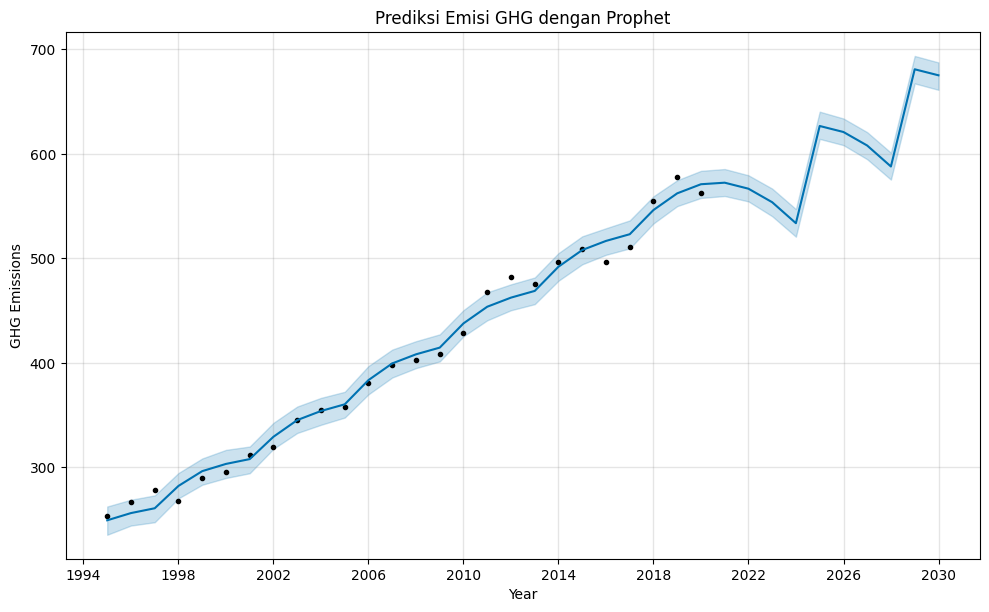

In [ ]:
# Membuat dataframe prediksi 10 tahun ke depan
future = model_prophet.make_future_dataframe(periods=10, freq='Y')

# Prediksi
forecast_prophet = model_prophet.predict(future)

model_prophet.plot(forecast_prophet)
plt.title('Prediksi Emisi GHG dengan Prophet')
plt.xlabel('Year')
plt.ylabel('GHG Emissions')

plt.show()

Interpretasi

Grafik menunjukkan prediksi Production-Based GHG Emission selama 10 tahun kedepan.

1. Tren jangka panjang

    - Garis biru utama mewakili tren prediksi emisi GHG. dari grafik terlihat bahwa model ini memperlihatkan peningkatan yang stabil  dengan lonjakan signifikan di beberapa titik.
    - Tren mengikuti pola peningkatan yang konsisten di data historis

2. Interval Ketidakpastian

    - Area biru muda di sekitar garis prediksi adalah Interval Ketidakpastian. Semakin lebar area tersebut maka semakin besar ketidakpastian pada prediksi.

3. Data Historis dan Prediksi

    - Titik-titik hitam tersebut adalah data historis yang digunakan untuk melatih model dan setelah data historis (2020) garis biru menunjukkan preyeksi masa depan selama 10 tahun kedepan.
    

## 4. Evaluasi Model

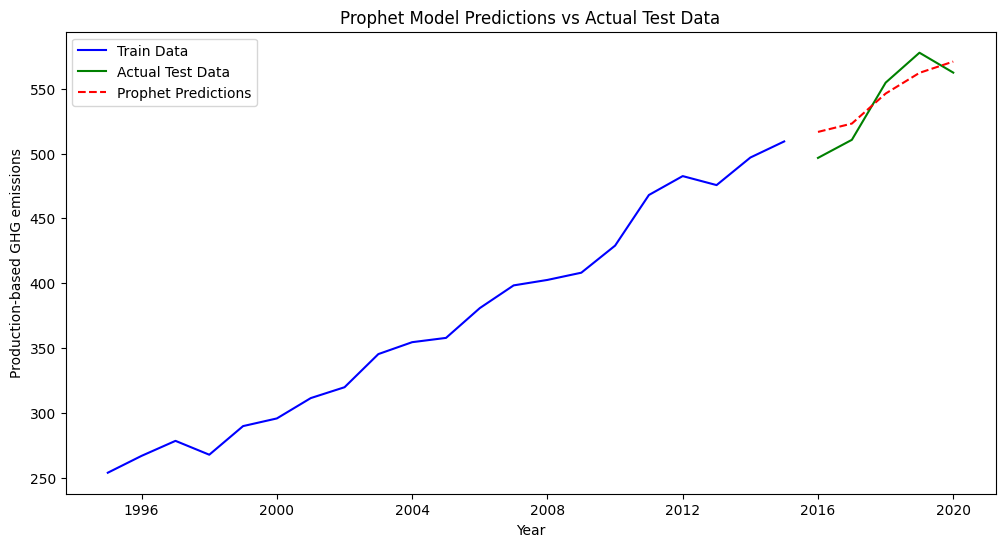

In [ ]:
train_data = emisi_ghg_prophet[emisi_ghg_prophet['ds'] <= '2015']
test_data = emisi_ghg_prophet[emisi_ghg_prophet['ds'] > '2015']
forecast_test = forecast_prophet[forecast_prophet['ds'].isin(test_data['ds'])]

plt.figure(figsize=(12, 6))

# Plot data latih
plt.plot(train_data['ds'], train_data['y'], label='Train Data', color='blue')

# Plot data uji
plt.plot(test_data['ds'], test_data['y'], label='Actual Test Data', color='green')

# Plot prediksi Prophet pada periode data uji
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet Predictions', color='red', linestyle='--')

plt.title('Prophet Model Predictions vs Actual Test Data')
plt.xlabel('Year')
plt.ylabel('Production-based GHG emissions')
plt.legend()

plt.show()

interpretasi

1. Train Data

    - Garis biru menunjukkan data historis yang digunakan untuk melatih model Prophet (hingga tahun 2015). hal ini menunjukkan pola tren dari data emisi GHG yang meningkat secara konsisten selama periode waktu ini.

2. Actual Test Data

    - Garis hijau solid mewakili data aktual setelah periode data latih (tahun 2016 ke atas). data ini digunakan untuk mengevaluasi akurasi prediksi Prophet.

3. Prophet Prediction

    - Garis merah putus-putus menunjukkan prediksi model Prophet. Prediksi ini mengikuti tren data uji aktual dengan baik, tetapi ada beberapa perbedaan pada titik tertentu.
    - Model Prephet ini berhasil menangkap pola keseluruhan tren emisi GHG pada data uji.

Grafik ini menunjukkan bahwa model Prophet mampu menangkap tren umum dalam data historis dan membuat prediksi yang cukup akurat untuk data di masa depan. Dengan hasil ini, model Prophet dapat diandalkan untuk membuat proyeksi jangka panjang terkait emisi GHG, meskipun ada beberapa margin kesalahan yang wajar di beberapa titik data.

## Metric Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_data['y'], forecast_test['yhat'])
mse = mean_squared_error(test_data['y'], forecast_test['yhat'])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_data['y'] - forecast_test['yhat']) / test_data['y'])) * 100

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

MAE: 13.006513779720512
MSE: 188.66756826915034
RMSE: 13.735631338571604
MAPE: 2.4418070159360776%


Interpretasi

1. Mean Absolute Error (MAE): 13.01
    Menunjukkan bahwa prediksi model Prophet rata-rata meleset sekitar 13 unit emisi GHG dari nilai aktual pada data uji.

2. Mean Squared Error (MSE): 188.67
     Menunjukkan ada beberapa kesalahan prediksi yang lebih signifikan, meskipun secara keseluruhan cukup moderat.

3. Root Mean Squared Error (RMSE): 13.74
    menunjukkan besarnya rata-rata kesalahan prediksi pada skala data emisi GHG. RMSE yang mendekati MAE menunjukkan bahwa kesalahan model relatif konsisten tanpa outliers besar.

4. Mean Absolute Percentage Error (MAPE): 2.44%
    menunjukkan bahwa model Prophet memiliki kesalahan prediksi rata-rata sekitar 2.44% dari nilai emisi aktual. Ini adalah nilai yang sangat baik, menunjukkan bahwa model memiliki akurasi yang tinggi dalam memprediksi data uji.

Akurasi Tinggi: MAPE yang rendah (2.44%) menunjukkan bahwa model Prophet memiliki akurasi yang baik dalam memprediksi emisi GHG pada data uji.

Dengan tingkat kesalahan yang relatif kecil, model Prophet ini dapat diandalkan untuk memproyeksikan tren emisi GHG di masa depan, yang bisa sangat bermanfaat untuk perencanaan kebijakan lingkungan atau analisis tren jangka panjang.